# **04. CLTV Using Probabilistic Models**

## **Introduction**

We aim to compute __Customer Lifetime Value (CLTV)__ using a __probabilistic modeling approach__. Specifically, we will apply the __BG/NBD__ , __Pareto/NBD__ and __MBG/NBD models to estimate customer purchasing behavior over time. In addition, the __Gamma-Gamma model__  will be used to evaluate the expected monetary value of transactions. Together, these models allow us to estimate the average profit that can be generated from each customer, providing a robust framework for understanding long-term customer profitability. Identify high-value customers for retention strategies and do customer profile to understand better and enable targeted marketing, personalized offers and improve customer retention.


### **Key Objectives**

* **Quantify customer value** using BG/NBD and Pareto/NBD probabilistic models
* **Predict purchase frequency** and customer churn/active probability
* **Estimate transaction value** using Gamma-Gamma modeling
* **Segment customers** for targeted retention strategies
* **Customer profiling** for improve customer retention, personalized offers and enable target marketing.


### **Methodology**

* **RFM Analysis**: Recency, Frequency, Monetary metrics
* **BG/NBD Model**: Predicts repeat purchase patterns and customer lifetime
* **Pareto/NBD Model**: Alternative approach using Pareto distribution for churn
* **Gamma-Gamma Model**: Estimates average customer transaction value
* **Probability of Survival**: Calculates likelihood of customer remaining active


## **1. Import Libraries & Load Dataset**

In [1]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sidetable
from pathlib import Path
from IPython.display import display
from IPython.display import Markdown

import lifetimes
from lifetimes import BetaGeoFitter, ParetoNBDFitter, ModifiedBetaGeoFitter
from lifetimes.plotting import plot_frequency_recency_matrix
from lifetimes.plotting import plot_probability_alive_matrix
from lifetimes.plotting import plot_period_transactions
from lifetimes.utils import calibration_and_holdout_data
from lifetimes.plotting import *
from sklearn.metrics import mean_squared_error
from math import sqrt
from lifetimes.plotting import plot_history_alive
import pickle
from lifetimes import GammaGammaFitter
from scipy.stats import norm, gamma, beta
from sklearn.metrics import mean_squared_error




In [2]:
# display setting
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", None)

import warnings
warnings.simplefilter("ignore", category=FutureWarning)

# Display markdown formatted output like bold, italic bold etc.'''
def display_md(string):
    display(Markdown(string))

    

In [3]:
# Define paths to read files
parent_path = Path.cwd().parent
data_path = parent_path.joinpath('data', 'processed')

files = []
for file in data_path.rglob('*.csv'):
    files.append(file)
    print(files.index(file), ' ', file.name)

0   cltv_df.csv
1   customer_segmentation.csv
2   customer_segmentation_cltv.csv
3   kmeans_df.csv
4   ParetoNBD_GammaGamma_CLTV_Analysis.csv
5   processed_cltv_segmentation.csv
6   processed_data.csv


In [4]:
display_md("**Loading Processed & Segmented Dataset...**")
try:
    processed_df = pd.read_csv(data_path.joinpath('processed_data.csv'))
    customer_seg_df = pd.read_csv(data_path.joinpath('customer_segmentation.csv'))
    
    # standardize the column names
    processed_df.columns = processed_df.columns.str.strip().str.replace(" ", "_").str.replace(".", "_")
    customer_seg_df.columns = customer_seg_df.columns.str.strip().str.replace(" ", "_").str.replace(".", "_")

    # take a copy of original dataframe
    customer_df = processed_df.copy()
    
    # Conversion of 'Dt_Customer' into datetime
    customer_df['Dt_Customer'] = pd.to_datetime(customer_df['Dt_Customer'], format='%Y-%m-%d')
    customer_seg_df['Dt_Customer'] = pd.to_datetime(customer_seg_df['Dt_Customer'], format='%Y-%m-%d')
    display_md(f"**Dataset Shape : {customer_df.shape}**")
    display_md(f"**Number of duplicate rows in dataset : {customer_df.duplicated().sum()}**")
    
except Exception as e:
    print(f"Error raised while loading file : {e}")



**Loading Processed & Segmented Dataset...**

**Dataset Shape : (2214, 39)**

**Number of duplicate rows in dataset : 0**

The dataset has been thoroughly cleaned and preprocessed, making it ready for the application of probabilistic modeling techniques.

## **2. Basic Information**

In [5]:
# Compute tenure in days for model requirements
customer_df['T'] = (
    (
        customer_df['Dt_Customer'].max() - customer_df['Dt_Customer']
    ).dt.days
    
)
customer_df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,Age,Is_parent,Children,Day,Month,Quarter,Year,Monetary,Frequency,Tenure,T
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,88,546,172,88,88,3,8,10,4,7,0,0,0,0,0,0,3,11,1,58,0,0,4,9,3,2012,1617,22,28,663
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,1,6,2,1,6,2,1,1,2,5,0,0,0,0,0,0,3,11,0,61,1,2,8,3,1,2014,27,4,9,113
2,4141,1965,Graduation,Partner,71613.0,0,0,2013-08-21,26,426,49,127,111,21,42,1,8,2,10,4,0,0,0,0,0,0,3,11,0,50,0,0,21,8,3,2013,776,20,16,312
3,6182,1984,Graduation,Partner,26646.0,1,0,2014-02-10,26,11,4,20,10,3,5,2,2,0,4,6,0,0,0,0,0,0,3,11,0,31,1,1,10,2,1,2014,53,6,10,139
4,5324,1981,PhD,Partner,58293.0,1,0,2014-01-19,94,173,43,118,46,27,15,5,5,3,6,5,0,0,0,0,0,0,3,11,0,34,1,1,19,1,1,2014,422,14,11,161


In [6]:
rfm_df = customer_df[['ID', 'Recency', 'Frequency', 'Monetary', 'T']].copy()
rfm_df.head()

,ID,Recency,Frequency,Monetary,T
0,5524,58,22,1617,663
1,2174,38,4,27,113
2,4141,26,20,776,312
3,6182,26,6,53,139
4,5324,94,14,422,161


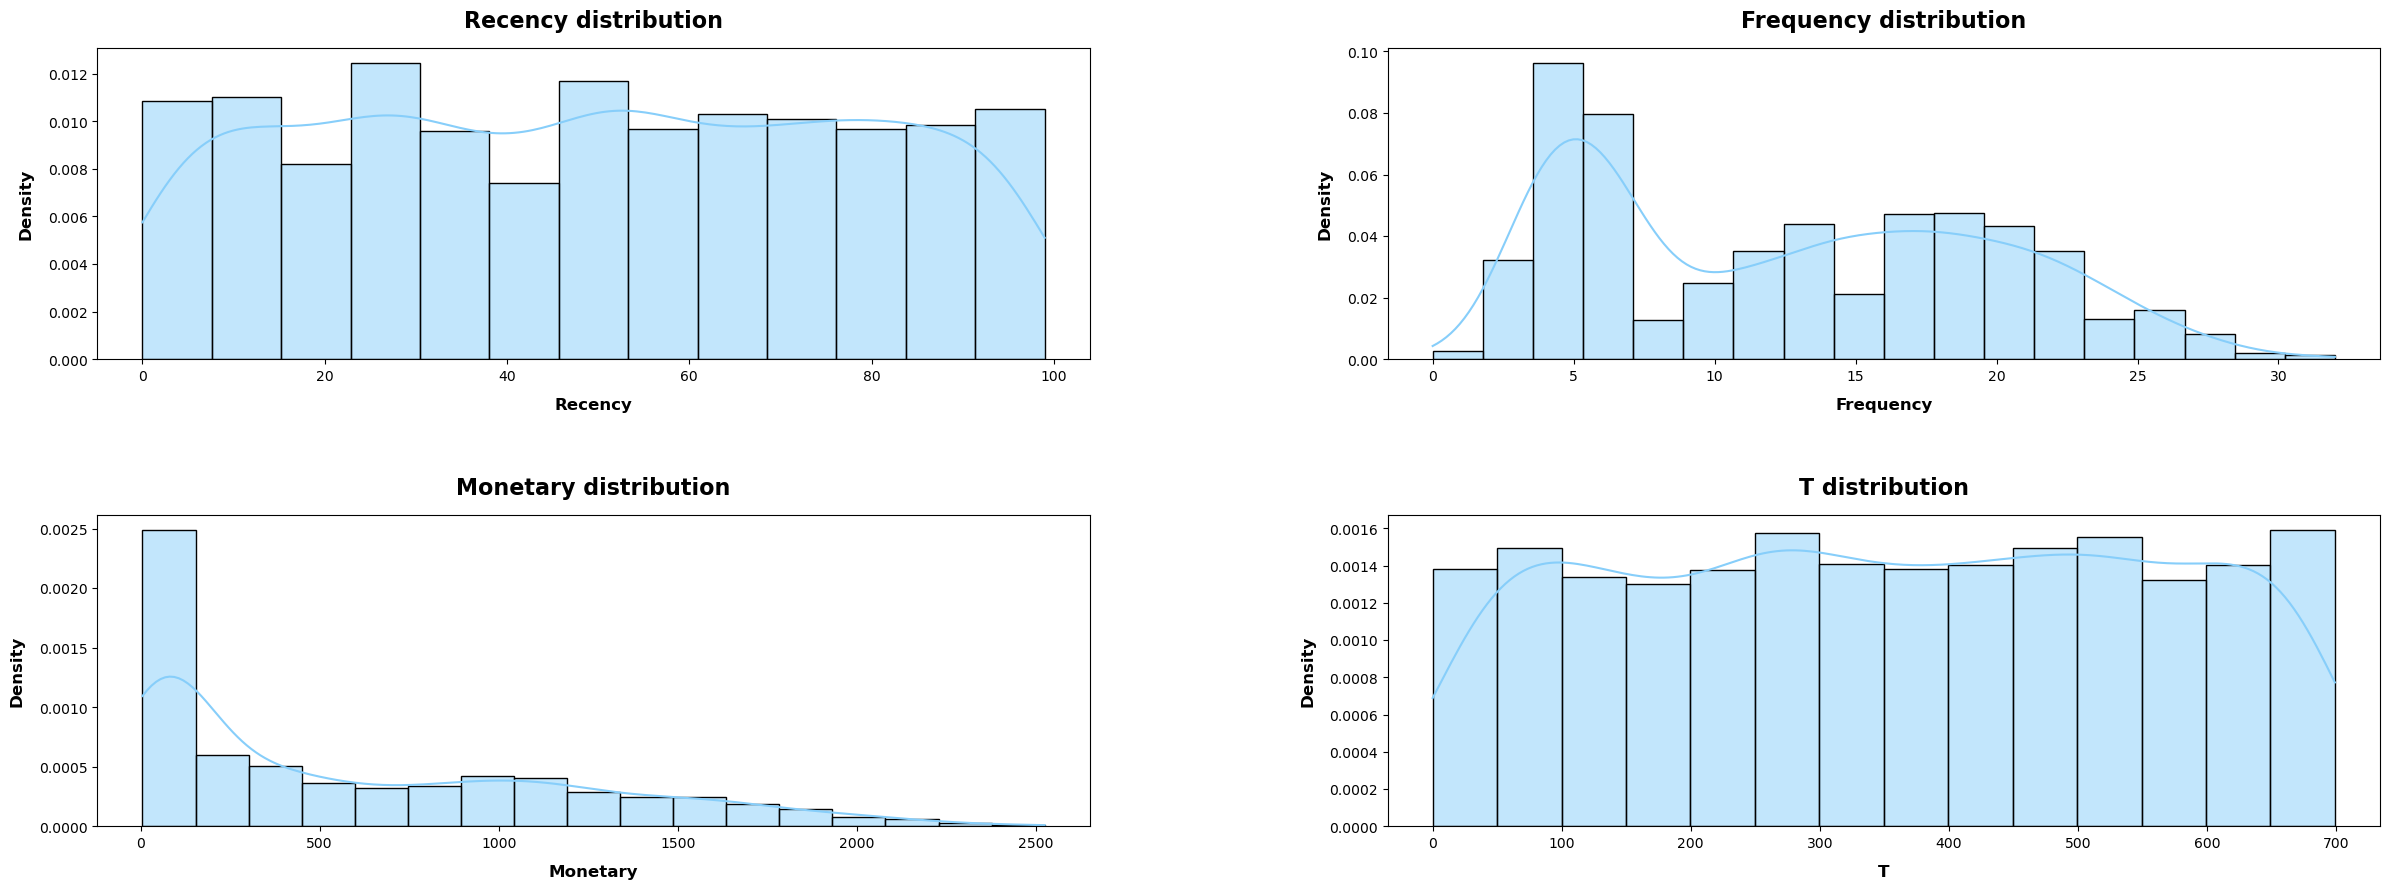

In [7]:
# plotting distriution of RFM-T features
fig, ax = plt.subplots(2, 2, figsize=(24, 9))
ax=ax.flatten()
for i, col in enumerate(['Recency', 'Frequency', 'Monetary', 'T']):
    sns.histplot(data=customer_df, x=col, stat='density', kde=True, color='lightskyblue', ax=ax[i])
    ax[i].set_title(f"{col} distribution", fontsize=16, fontweight='bold', y=1.04)
    ax[i].set_xlabel(f"{col}", fontsize=12, fontweight='bold', labelpad=10)
    ax[i].set_ylabel('Density', fontsize=12, fontweight='bold', labelpad=10)

plt.tight_layout()
plt.subplots_adjust(wspace=0.3, hspace=0.5)
plt.show()


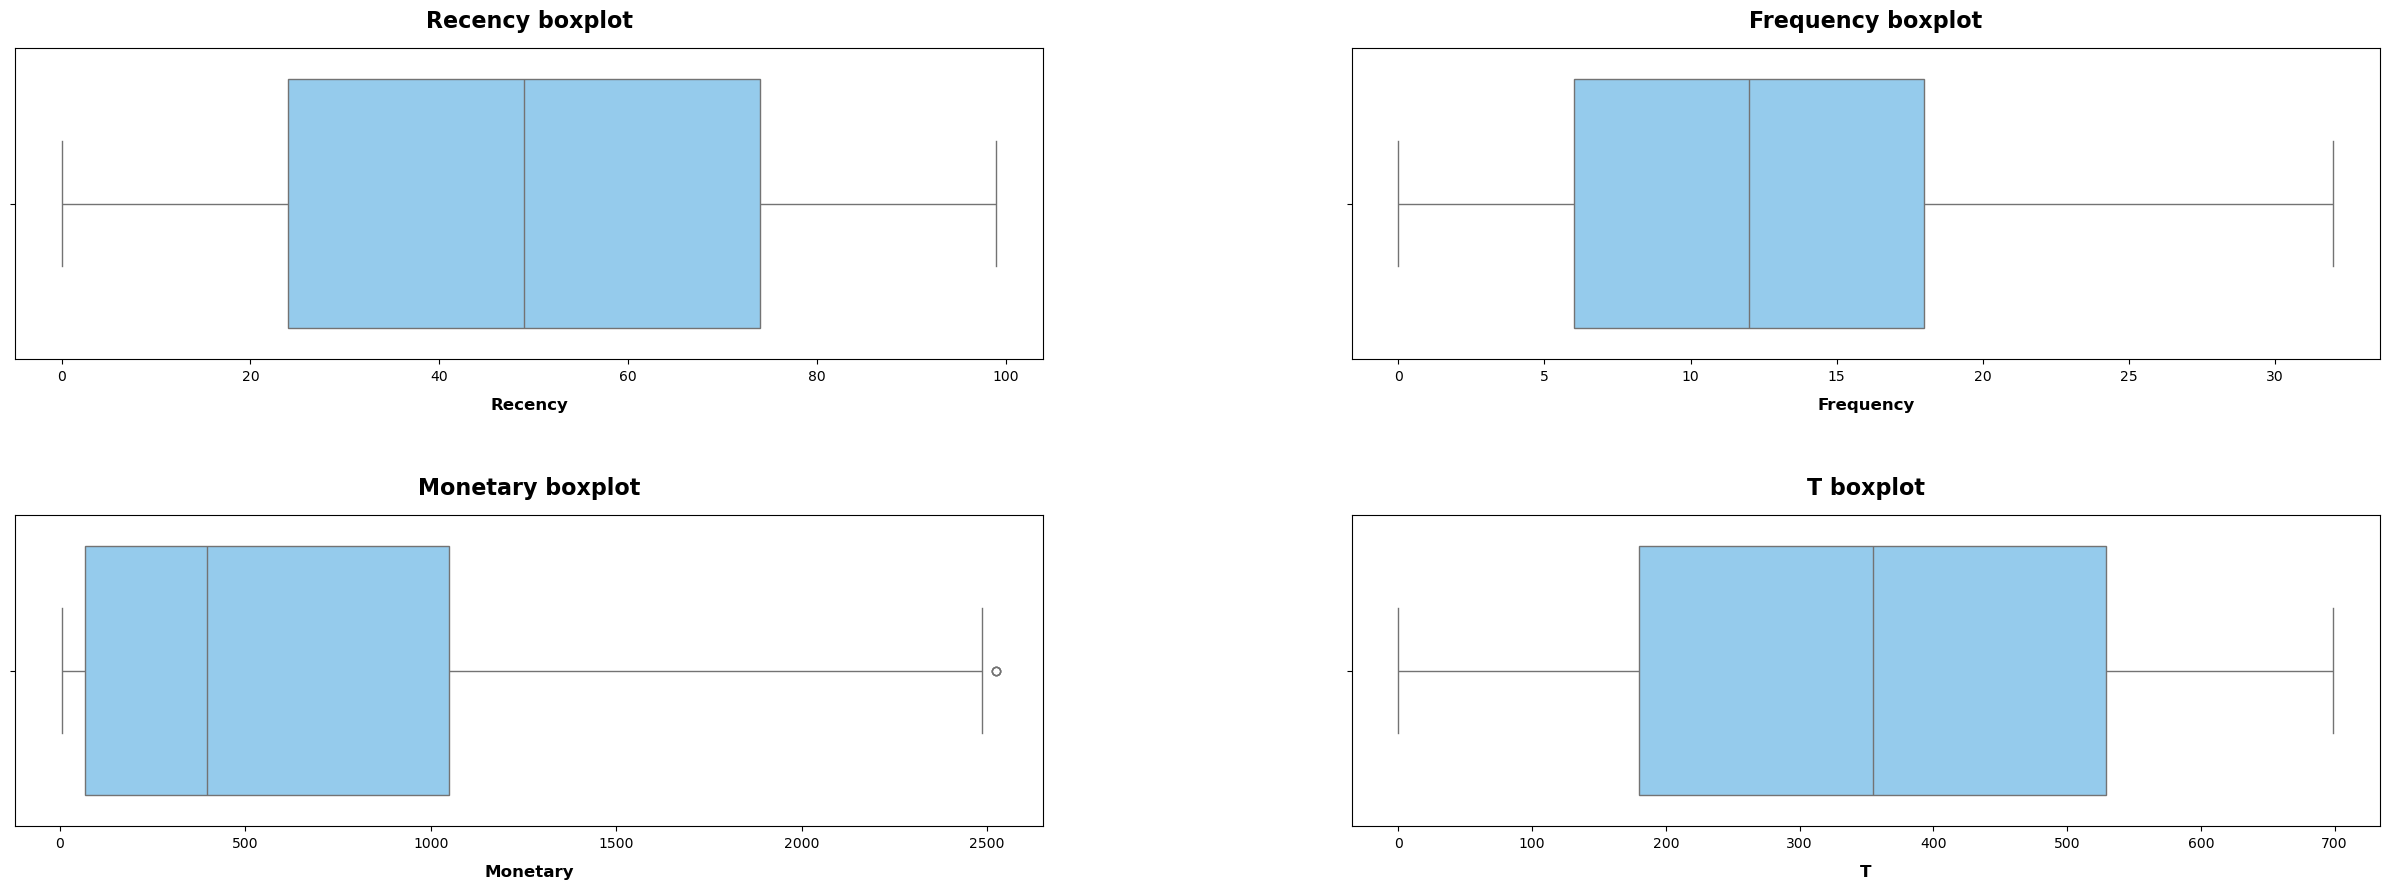

In [8]:
# plotting distriution of RFM-T features
fig, ax = plt.subplots(2, 2, figsize=(24, 9))
ax=ax.flatten()
for i, col in enumerate(['Recency', 'Frequency', 'Monetary', 'T']):
    sns.boxplot(data=customer_df, x=col, color='lightskyblue', ax=ax[i])
    ax[i].set_title(f"{col} boxplot", fontsize=16, fontweight='bold', y=1.04)
    ax[i].set_xlabel(f"{col}", fontsize=12, fontweight='bold', labelpad=10)
    #ax[i].set_ylabel('Density', fontsize=12, fontweight='bold', labelpad=10)

plt.tight_layout()
plt.subplots_adjust(wspace=0.3, hspace=0.5)
plt.show()


In [9]:
rfm_df.describe()

,ID,Recency,Frequency,Monetary,T
count,2214.000000,2214.000000,2214.000000,2214.000000,2214.000000
mean,5588.462511,49.032520,12.565041,607.547425,353.486902
std,3248.656750,28.953612,7.202705,602.967666,202.522900
min,0.000000,0.000000,0.000000,5.000000,0.000000
25%,2817.750000,24.000000,6.000000,69.000000,180.000000
50%,5458.500000,49.000000,12.000000,397.000000,355.000000
75%,8419.500000,74.000000,18.000000,1048.000000,529.000000
max,11191.000000,99.000000,32.000000,2525.000000,699.000000


In [10]:
#checking for the values containing zero.

print(f"Total Number of Frequency with 0 : {len(rfm_df[rfm_df["Frequency"] == 0])}")
print(f"Total Number of Recency with 0 : {len(rfm_df[rfm_df["Recency"] == 0])}")
print(f"Total Number of Monetary Value with 0 : {len(rfm_df[rfm_df["Monetary"] == 0])}")


Total Number of Frequency with 0 : 6
Total Number of Recency with 0 : 28
Total Number of Monetary Value with 0 : 0


In this project, CLV is predicted at the customer level rather than at the cohort or aggregate level. This approach allows us to capture individual customer behavior for more personalized insights.



## **3. Probabilistic Modeling Techniques**

These models answer simple question : **How many more times is this customer likely to purchase from us?**

Will use these approaches :

* **BG/NBD** : BG/NBD model (Beta-Geometric/Negative Binomial Distribution) is designed to predict how often customers will make repeat purchases and when they might stop buying altogether. It assumes that each customer has a certain probability of 'dropping out/inactive/churn', and that probability varies across the customer base.
* **Pareto/NBD** : Pareto/NBD model works in a similar way but uses a Pareto distribution to model dropout behavior. It is often considered more flexible and can provide slightly different insights into customer retention compared to BG/NBD.
* **MBG/NBD** : MBG/NBD (Modified Beta-Geometric/Negative Binomial Distribution) is designed to predict how often customers will make repeat purchases and whether they are likely to become inactive (churn). It assumes that customers have different purchase rates and churn probabilities, which vary across the customer base.
* **Gamma-Gamma Model** : Gamma-Gamma model complements these by focusing on the monetary side. It estimates the average transaction value for each customer, assuming that while customers differ in how much they spend, their spending habits remain consistent over time.

__NOTE__ : Probabilistic Model assumptions:
* **Frequency > 0**: Customer has made at least one repeat purchase.
* **Recency ≤ T**: Customer's last purchase occurred within the observation period.


In [22]:
df_rfm = rfm_df.copy()
# Assumptions of probablistic models
# Exclude one-time buyers
data = df_rfm[df_rfm['Frequency'] > 0].copy()

# Ensure Recency <= Tenure
rfm_data = data[data['Recency'] <= data['T']]


# Dictionary of probabilistic models
models = {
    "BG/NBD": BetaGeoFitter(penalizer_coef=0.001),
    "Pareto/NBD": ParetoNBDFitter(penalizer_coef=0.001),
    "MBG/NBD": ModifiedBetaGeoFitter(penalizer_coef=0.001)
}

# Train each model
model_dataframes = {}

for name, model in models.items():

    # Train model
    model.fit(
        rfm_data["Frequency"],
        rfm_data["Recency"],
        rfm_data["T"]
    )

    # Expected purchases for next 90 days (or 3 months)
    predictions = model.conditional_expected_number_of_purchases_up_to_time(
        3*30,
        rfm_data["Frequency"],
        rfm_data["Recency"],
        rfm_data["T"]
    )

    # Actual purchases for next 90 days (or 3 months)
    rfm_data['Actual_90'] = ((rfm_data['Frequency']/rfm_data['Recency'])*90)

    # Create separate dataframe
    temp_df = pd.DataFrame({
        "ID": rfm_data["ID"],
        "Actual_Purchases": rfm_data['Actual_90'],
        "Predicted_Purchases": predictions
    })

    model_dataframes[name] = temp_df    

    print(f"{name} trained successfully")

    

BG/NBD trained successfully
Pareto/NBD trained successfully
MBG/NBD trained successfully


In [23]:
results = []
for model_name, model_df in model_dataframes.items():
    model_df = model_df.replace([np.inf, -np.inf], np.nan).fillna(0)
    mse = mean_squared_error(model_df["Actual_Purchases"], model_df["Predicted_Purchases"])
    rmse = np.sqrt(float(mse))
    avg_error = (model_df["Actual_Purchases"] - model_df["Predicted_Purchases"]).mean()

    results.append({
        'Model': model_name,
        'MSE': mse,
        'RMSE': rmse,
        'Average_Error': avg_error
    })

model_results_df = pd.DataFrame(results)
model_results_df.index = model_results_df['Model']
model_results_df.drop(columns=['Model'], inplace=True)
display(model_results_df.style.highlight_min(axis='index', color='lightgreen').format("{:.2f}"))


,MSE,RMSE,Average_Error
Model,,,
BG/NBD,31146.46,176.48,63.33
Pareto/NBD,31065.44,176.25,63.30
MBG/NBD,31143.99,176.48,63.31


**Overall, the models show similar performance. However, the Pareto/NBD model performs slightly better, as it has the lowest MSE and RMSE values. Will use Pareto/NBD + Gamma-Gamma model to compute CLTV.**


## **Pareto - Negative Binomial Distribution + Gamma Gamma Distribution Model**

In [24]:
best_model_name = model_results_df['MSE'].idxmin()
best_model = models[best_model_name]

print("Best Model:", best_model_name)
print("\nParameters:")
print(best_model.params_)


Best Model: Pareto/NBD

Parameters:
r           0.562175
alpha       0.691714
s          66.276240
beta     3620.172540
dtype: float64


| Customer behavior | Distribution | Denoted by | Parameters |
|---|---|---|---|
| Purchase rate | Gamma distribution | λ | r, α |
| Dropout rate | Gamma distribution | μ | s, β |
| Individual purchase process | Poisson process | — | λ |
| Individual dropout process | Exponential distribution | — | μ |


$\lambda \sim \mathrm{Gamma}(r,\alpha)$

Simply means, **Gamma → captures heterogeneity in purchase rates; $\lambda$ denotes an individual customer's purchase rate.**



$\mu \sim \mathrm{Gamma}(s,\beta)$

Simply means, **Gamma → captures heterogeneity in dropout rates; $\mu$ denotes an individual customer's dropout rate.**


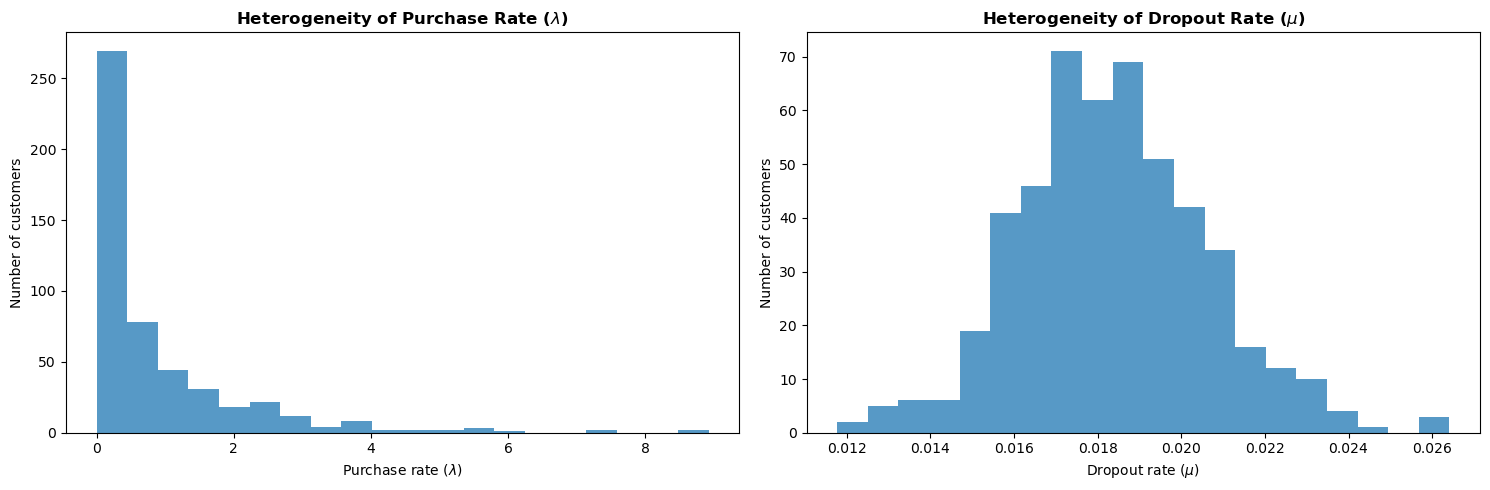

In [25]:
# Purchase-rate distribution
lambda_dist = gamma.rvs(
    a=best_model.params_['r'],
    scale=1 / best_model.params_['alpha'],
    size=500
)

# Dropout-rate distribution
mu_dist = gamma.rvs(
    a=best_model.params_['s'],
    scale=1 / best_model.params_['beta'],
    size=500
)

fig, ax = plt.subplots(1, 2, figsize=(15, 5))

ax[0].set_title(r'Heterogeneity of Purchase Rate ($\lambda$)', fontsize=12, fontweight='bold')
ax[0].hist(lambda_dist, bins=20, alpha=0.75)
ax[0].set_xlabel(r'Purchase rate ($\lambda$)')
ax[0].set_ylabel('Number of customers')

ax[1].set_title(r'Heterogeneity of Dropout Rate ($\mu$)', fontsize=12, fontweight='bold')
ax[1].hist(mu_dist, bins=20, alpha=0.75)
ax[1].set_xlabel(r'Dropout rate ($\mu$)')
ax[1].set_ylabel('Number of customers')

plt.tight_layout()
plt.subplots_adjust(wspace=0.1, hspace=0.1)
plt.show()


In [26]:
rfm_pareto = rfm_data[['ID', 'Frequency', 'Recency', 'Monetary', 'T']].merge(model_dataframes[best_model_name], on='ID', how='left')
display(rfm_pareto.head())


,ID,Frequency,Recency,Monetary,T,Actual_Purchases,Predicted_Purchases
0,5524,22,58,1617,663,34.137931,2.516544e-27
1,2174,4,38,27,113,9.473684,2.179110e-02
2,4141,20,26,776,312,69.230769,8.974190e-23
3,6182,6,26,53,139,20.769231,6.844778e-05
4,5324,14,94,422,161,13.404255,4.706186e-03


**Visualizing frequency/recency matrix**

In the Pareto/NBD model, the matrix usually plots:

* __Frequency__ = number of repeat purchases
* __Recency__ = time between the customer's first and most recent purchase
* __T__ = total observation period


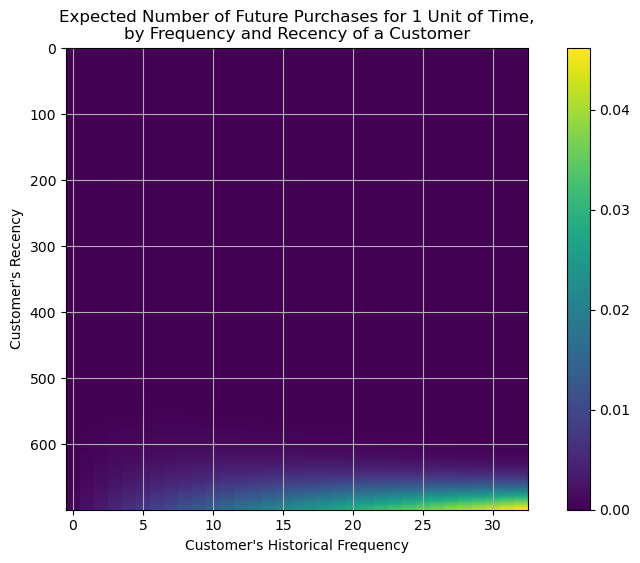

In [27]:

# plotting the frequency & recency matrix (computes the expected number of transactions a customer is to make in the next time period, given the R(age at last purchase) and F (the number of repeat transactions made))
plt.figure(figsize=(10, 6))
plot_frequency_recency_matrix(best_model)

plt.grid(axis='both')
plt.show()


**Churn Matrix**

A churn matrix from the Pareto/NBD model shows the probability that a customer is still active vs. has become inactive (churned) based mainly on their frequency and recency.

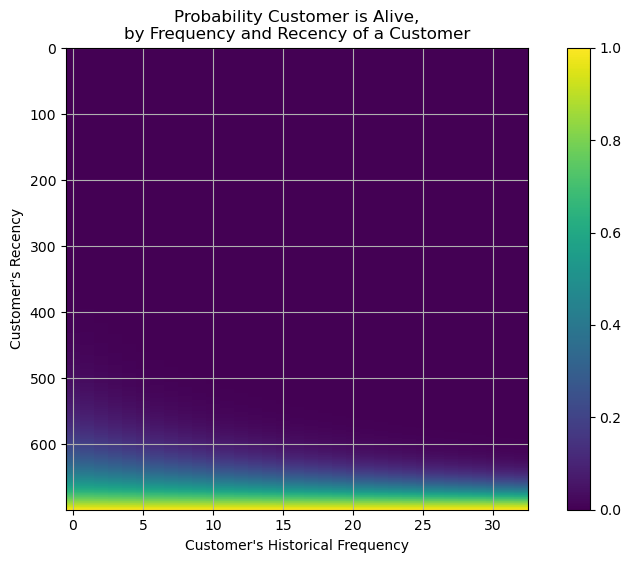

In [28]:
# plotting the churn matrix/ probability of active customer
plt.figure(figsize=(10, 6))
plot_probability_alive_matrix(best_model)

plt.grid(axis='both')
plt.show()


**Interpretation of Frequency/Recency + Churn Matrix**

| **Frequency** | **Recency** | **Churn Probability** | **Customer Status** | **Characteristic + Segment** | **Business Action** |
|---|---|---|---|---|---|
| **High** | **High** | **Low** | **Active** | Frequent and recently active → **Loyal customers** | Retain, reward & personalize |
| **High** | **Low** | **Medium** | **At Risk / Active** | Previously frequent but activity is older → **At-risk loyal customers** | Re-engage with targeted offers |
| **Low** | **High** | **Medium–Low** | **Active** | Few purchases but relatively recent activity → **New/promising customers** | Nurture & upsell & cross-sell |
| **Low** | **Low** | **High** | **Inactive** | Few purchases and little recent activity → **Likely churned/inactive** | Win-back selectively or deprioritize |

__Key takeaway__

* __Recency dominates__: recent activity is the strongest predictor of being alive.
* __Frequency amplifies churn signals__: if a heavy buyer stops, it's more alarming than if a light buyer stops.



In [29]:
# Compute probablity of alive of eachh customer
rfm_pareto['p_alive'] = best_model.conditional_probability_alive(
    rfm_pareto['Frequency'],
    rfm_pareto['Recency'],
    rfm_pareto['T']
).round(4)

rfm_pareto['p_not_alive'] = 1 - best_model.conditional_probability_alive(
    rfm_pareto['Frequency'],
    rfm_pareto['Recency'],
    rfm_pareto['T']
).round(4)

display(rfm_pareto.head())


,ID,Frequency,Recency,Monetary,T,Actual_Purchases,Predicted_Purchases,p_alive,p_not_alive
0,5524,22,58,1617,663,34.137931,2.516544e-27,0.0000,1.0000
1,2174,4,38,27,113,9.473684,2.179110e-02,0.0120,0.9880
2,4141,20,26,776,312,69.230769,8.974190e-23,0.0000,1.0000
3,6182,6,26,53,139,20.769231,6.844778e-05,0.0000,1.0000
4,5324,14,94,422,161,13.404255,4.706186e-03,0.0011,0.9989


In [30]:
total_customers = rfm_pareto.shape
not_alive_customers = rfm_pareto.query('p_alive==0').shape

display_md(f"**Total percentage of churn/dropout customers** : {100 * not_alive_customers[0]/total_customers[0]:.1f}%")


**Total percentage of churn/dropout customers** : 84.1%

**Ranking customers from best to worst**

We can rank our customers by who is expected to make the most purchases in the next period, down to those expected to make the least. The model uses each customer's purchase history to predict their future buying activity.

In [31]:
display_md("**Top 10 customers expected to make the most purchases in the next 3 months**")
display(rfm_pareto.sort_values(by = "Predicted_Purchases", ignore_index=True).round(4).tail(10))

display_md("**Insight:**")

display_md("This approach helps identify **high-value** customers who are most likely to buy again soon. Companies can then focus campaigns, loyalty programs, or personalized offers on these customers to maximize ROI.")



**Top 10 customers expected to make the most purchases in the next 3 months**

,ID,Frequency,Recency,Monetary,T,Actual_Purchases,Predicted_Purchases,p_alive,p_not_alive
2055,5558,14,90,1685,90,14.0000,7.2173,1.0000,0.0000
2056,3830,15,59,459,66,22.8814,7.6828,0.7353,0.2647
2057,8566,3,10,9,14,27.0000,9.4640,0.8792,0.1208
2058,2963,20,56,1440,58,32.1429,14.8704,0.9492,0.0508
2059,7723,20,56,1440,58,32.1429,14.8704,0.9492,0.0508
2060,10767,20,40,1346,44,45.0000,16.7153,0.8143,0.1857
2061,6892,20,23,732,26,78.2609,27.6441,0.8067,0.1933
2062,2546,5,7,70,7,64.2857,32.0689,1.0000,0.0000
2063,9888,15,3,1091,4,450.0000,123.5410,0.8403,0.1597
2064,4399,15,3,1091,4,450.0000,123.5410,0.8403,0.1597


**Insight:**

This approach helps identify **high-value** customers who are most likely to buy again soon. Companies can then focus campaigns, loyalty programs, or personalized offers on these customers to maximize ROI.

**Model Evaluation**

To evaluate the accuracy of our model, the first step is to compare the actual customer data with artificial data generated using the parameters from our fitted model.


<Figure size 800x400 with 0 Axes>

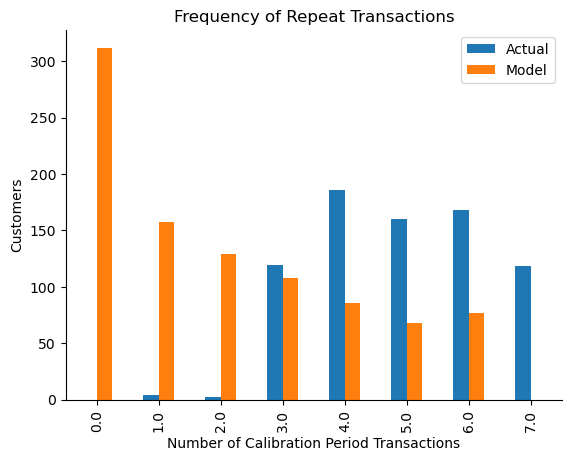

This chart compares actual customer purchase frequencies with those predicted by the best model during the calibration period.


**Insights**

Mid-range frequencies (3–6 transactions), the model's predictions are closer to reality, showing good calibration but low-frequeny(0-2) and high-frquency overestimates and underestimates respectively, compared with actual values.
CPU times: total: 3.66 s
Wall time: 6.11 s


In [32]:
%%time

plt.figure(figsize=(8, 4))
ax = plot_period_transactions(best_model)#, max_frequency=7)
sns.despine()
plt.show()

print("This chart compares actual customer purchase frequencies with those predicted by the best model during the calibration period.")
display_md("**Insights**")
print("Mid-range frequencies (3–6 transactions), the model's predictions are closer to reality, showing good calibration but low-frequeny(0-2) and high-frquency overestimates and underestimates respectively, compared with actual values.")


### Interpretation

* **X-axis:** Number of repeat transactions (0–8).
* **Y-axis:** Number of customers.
* **Blue bars:** Actual observed transactions.
* **Orange bars:** Model-simulated transactions.

### Insights

* **0–2 transactions:** Model **overestimates** low-frequency customers.
* **3–6 transactions:** Model predictions **closely match** actual data.
* **7–8 transactions:** Model **underestimates** high-frequency customers.

### Conclusion

The model captures the **overall purchasing pattern reasonably well**, but slightly struggles at the extremes—overpredicting infrequent buyers and underpredicting heavy buyers.



In [78]:
##NOTE : It has Dt_Customer, which is the customer enrollment date, not the purchase date. so can't calibrate model.

In [79]:
# Creating a function which can predict the future purchased value based on the specific period
def pnbd_model_prediction(t, id_):
    # select single row
    individual_row = rfm_pareto[rfm_pareto['ID']==id_].iloc[0]
    
    # predict the next purchase  in time t
    individual_pred = best_model.predict(t, individual_row['Frequency'], individual_row['Recency'], individual_row['T'])
    
    # Actual value
    actual_value = (individual_row['Frequency']/individual_row['Recency'])*t
    
    # Error
    error = actual_value - individual_pred

    print(f"Your Predicted Purchase : {individual_pred:.4f}")
    print(f"Your Actual Purchase : {actual_value:.4f}")
    print(f"Prediction Error : {error:.4f}")


# Apply on some customer id
print(pnbd_model_prediction(90, 5524))
print()
print("*"*40, end="\n\n")
print(pnbd_model_prediction(90, 2963))


Your Predicted Purchase : 0.0000
Your Actual Purchase : 34.1379
Prediction Error : 34.1379
None

****************************************

Your Predicted Purchase : 8.4329
Your Actual Purchase : 32.1429
Prediction Error : 23.7100
None


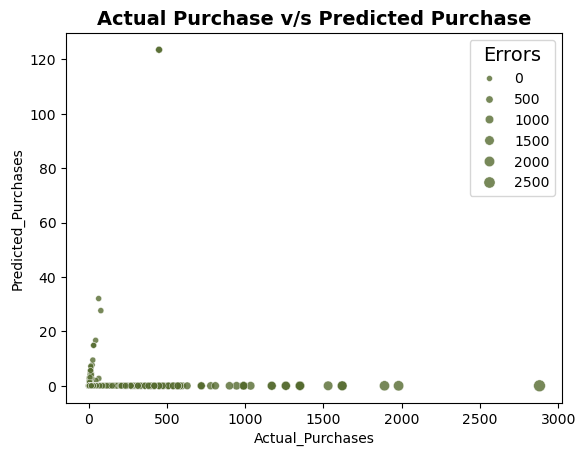

In [80]:
rfm_pnbd = rfm_pareto.replace([np.inf, -np.inf], np.nan).fillna(0)
# calculating the prediction error for the 30 days purchase prediction
error = rfm_pnbd["Actual_Purchases"] - rfm_pnbd["Predicted_Purchases"]

# Visualization
sns.scatterplot(rfm_pnbd, x= "Actual_Purchases", y= "Predicted_Purchases", size = error, color='darkolivegreen', alpha=0.8)
plt.title("Actual Purchase v/s Predicted Purchase", fontsize=14, fontweight='bold')
plt.legend(title='Errors', title_fontsize=14)
plt.show()


#### **Gamma Gamma Distribution Model**

In [81]:
rfm_ggd = rfm_pnbd[(rfm_pnbd['Frequency']>0) & (rfm_pnbd['Monetary'] > 0)]
display(rfm_ggd.head())
display_md(f'**Customers with atleast 1 repeat purchase** : {len(rfm_ggd)}')


,ID,Frequency,Recency,Monetary,T,Actual_Purchases,Predicted_Purchases,p_alive,p_not_alive
0,5524,22,58,1617,663,34.137931,2.516544e-27,0.0000,1.0000
1,2174,4,38,27,113,9.473684,2.179110e-02,0.0120,0.9880
2,4141,20,26,776,312,69.230769,8.974190e-23,0.0000,1.0000
3,6182,6,26,53,139,20.769231,6.844778e-05,0.0000,1.0000
4,5324,14,94,422,161,13.404255,4.706186e-03,0.0011,0.9989


**Customers with atleast 1 repeat purchase** : 2065

In [82]:
## Compute Actual Average Profit Per Transaction 
rfm_ggd.loc[:,'Actual_Avg_Monetary'] = rfm_ggd['Monetary'] / rfm_ggd['Frequency']

## Compute Average Profit Per Transaction using Gamam-Gamma Approach
# model fits in average sales per transaction 
ggf_pareto = GammaGammaFitter(penalizer_coef = 0.01)
ggf_pareto.fit(rfm_ggd['Frequency'], rfm_ggd['Actual_Avg_Monetary'])
display_md("**Gamma-Gamma Model Parameters :**")
display(ggf_pareto.summary)

rfm_ggd['Predicted_Avg_Monetary'] = ggf_pareto.conditional_expected_average_profit(rfm_ggd['Frequency'],rfm_ggd['Actual_Avg_Monetary'])
display_md('**RFM Dataset :**')
display(rfm_ggd.head())


**Gamma-Gamma Model Parameters :**

,coef,se(coef),lower 95% bound,upper 95% bound
p,3.474162,0.098856,3.280403,3.667921
q,0.845742,0.022733,0.801186,0.890298
v,3.421026,0.100205,3.224625,3.617427


**RFM Dataset :**

,ID,Frequency,Recency,Monetary,T,Actual_Purchases,Predicted_Purchases,p_alive,p_not_alive,Actual_Avg_Monetary,Predicted_Avg_Monetary
0,5524,22,58,1617,663,34.137931,2.516544e-27,0.0000,1.0000,73.500000,73.804457
1,2174,4,38,27,113,9.473684,2.179110e-02,0.0120,0.9880,6.750000,7.690625
2,4141,20,26,776,312,69.230769,8.974190e-23,0.0000,1.0000,38.800000,39.057763
3,6182,6,26,53,139,20.769231,6.844778e-05,0.0000,1.0000,8.833333,9.473611
4,5324,14,94,422,161,13.404255,4.706186e-03,0.0011,0.9989,30.142857,30.483897


Predicted Average Sales: 38.3707
Actual Average Sales: 37.8101
Difference: -0.5605
Mean Squared Error: 0.5408
Root Mean Squared Error: 0.7354


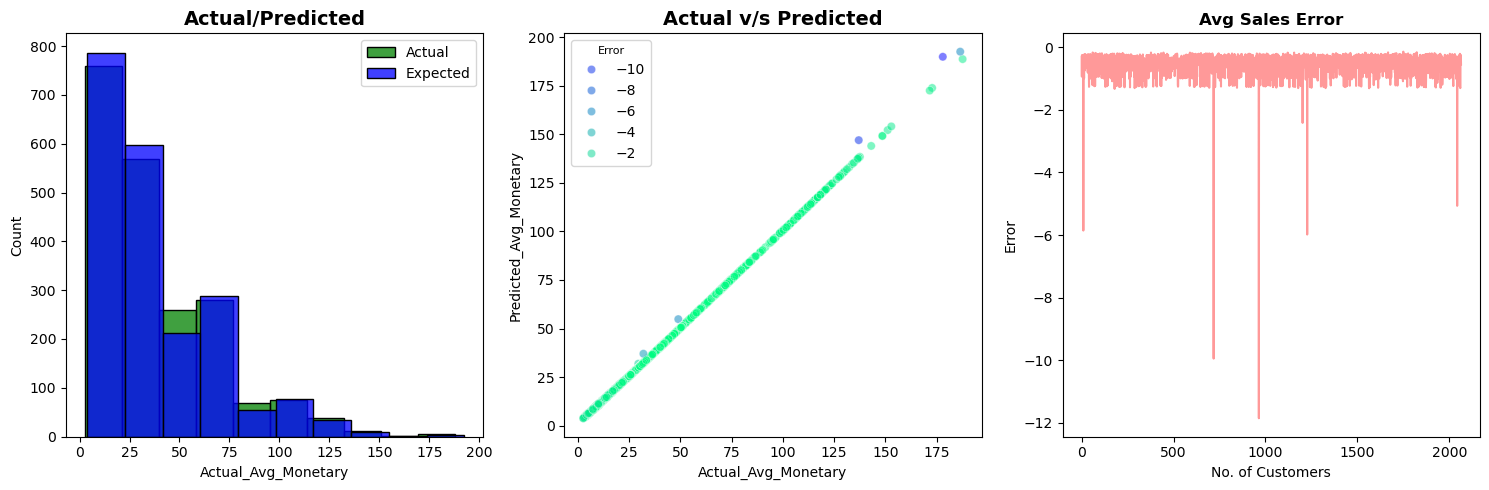

In [83]:
print(f"Predicted Average Sales: {rfm_ggd["Predicted_Avg_Monetary"].mean():.4f}")
print(f"Actual Average Sales: {rfm_ggd["Actual_Avg_Monetary"].mean():.4f}")
print(f"Difference: {(rfm_ggd["Actual_Avg_Monetary"].mean() - rfm_ggd["Predicted_Avg_Monetary"].mean()):.4f}")
print(f"Mean Squared Error: {(mean_squared_error(rfm_ggd["Actual_Avg_Monetary"], rfm_ggd["Predicted_Avg_Monetary"])):.4f}")
print(f"Root Mean Squared Error: {(sqrt(mean_squared_error(rfm_ggd["Actual_Avg_Monetary"], rfm_ggd["Predicted_Avg_Monetary"]))):.4f}")
      
# visualization
fig, ax = plt.subplots(1, 3, figsize=(15, 5))

sns.histplot(rfm_ggd["Actual_Avg_Monetary"], color = "g", bins=10, kde = False, ax = ax[0])
sns.histplot(rfm_ggd["Predicted_Avg_Monetary"], color = "b", bins=10, kde = False, ax=ax[0])
ax[0].set_title("Actual/Predicted", fontsize=14, fontweight='bold')
ax[0].legend(["Actual", "Expected"])

error = (rfm_ggd["Actual_Avg_Monetary"]-rfm_ggd["Predicted_Avg_Monetary"])

sns.scatterplot(data=rfm_ggd, x="Actual_Avg_Monetary", y="Predicted_Avg_Monetary", alpha = 0.5, hue = error, palette = "winter",ax=ax[1])
ax[1].set_title("Actual v/s Predicted", fontsize=14, fontweight='bold')
ax[1].legend(title='Error', title_fontsize=8)

ax[2].plot(error, color = 'r', alpha = 0.4)
ax[2].set_title("Avg Sales Error", fontsize=12, fontweight='bold')
ax[2].set_xlabel('No. of Customers')
ax[2].set_ylabel('Error')

plt.tight_layout()
plt.subplots_adjust(hspace=0.1)
plt.show()

## **CLTV using Gamma-Gamma Model + Pareto/NBD**

In [84]:
# Actual CLTV
# Manual predict clv = Predicted no. of transactions * Expected avg sales * profit_margin to compute profit from each transaction
profit_margin = 0.05
rfm_ggd['Actual_cltv'] = (rfm_ggd['Predicted_Purchases'] * rfm_ggd['Predicted_Avg_Monetary'] * profit_margin).map(lambda x: f"{x:.2f}").astype(float)


# The customers' lifetime values expected to in the next 3 months
rfm_ggd['Predicted_cltv'] = ggf_pareto.customer_lifetime_value(
    best_model,  # the model to use to predict the number of future transactions
    rfm_ggd['Frequency'],rfm_ggd['Recency'],rfm_ggd['T'],rfm_ggd['Actual_Avg_Monetary'],
    time=3,  #3 months
    freq="M",  #frequency information of T. In this case we set week by using 'D'
    discount_rate=0.01).map(lambda x: f"{x:.2f}").astype(float)

display(rfm_ggd.head())


c:\Users\Admin\anaconda3\envs\test_titanic\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


,ID,Frequency,Recency,Monetary,T,Actual_Purchases,Predicted_Purchases,p_alive,p_not_alive,Actual_Avg_Monetary,Predicted_Avg_Monetary,Actual_cltv,Predicted_cltv
0,5524,22,58,1617,663,34.137931,2.516544e-27,0.0000,1.0000,73.500000,73.804457,0.00,0.00
1,2174,4,38,27,113,9.473684,2.179110e-02,0.0120,0.9880,6.750000,7.690625,0.01,0.29
2,4141,20,26,776,312,69.230769,8.974190e-23,0.0000,1.0000,38.800000,39.057763,0.00,0.00
3,6182,6,26,53,139,20.769231,6.844778e-05,0.0000,1.0000,8.833333,9.473611,0.00,0.29
4,5324,14,94,422,161,13.404255,4.706186e-03,0.0011,0.9989,30.142857,30.483897,0.01,2.33


In [85]:
# Top 5 customers with high CLV
display_md("**Top 5 customers with high CLV**")
display(rfm_ggd[["ID", "Predicted_cltv"]].sort_values(by = "Predicted_cltv", ascending = False).head(5))
     

**Top 5 customers with high CLV**

,ID,Predicted_cltv
682,7875,22.84
1067,7959,22.72
956,9888,21.90
1343,4399,21.90
314,1826,21.74


,Actual,Predicted,Error
0,2509.137931,1.857322e-25,2509.137931
1,63.947368,1.675872e-01,63.779781
2,2686.153846,3.505118e-21,2686.153846
3,183.461538,6.484477e-04,183.460890
4,404.042553,1.434629e-01,403.899090


Average Error: 3173.7860087270165
Mean Squared Error: 125531153.65443903
Root Mean Squared Error: 11204.068620569897


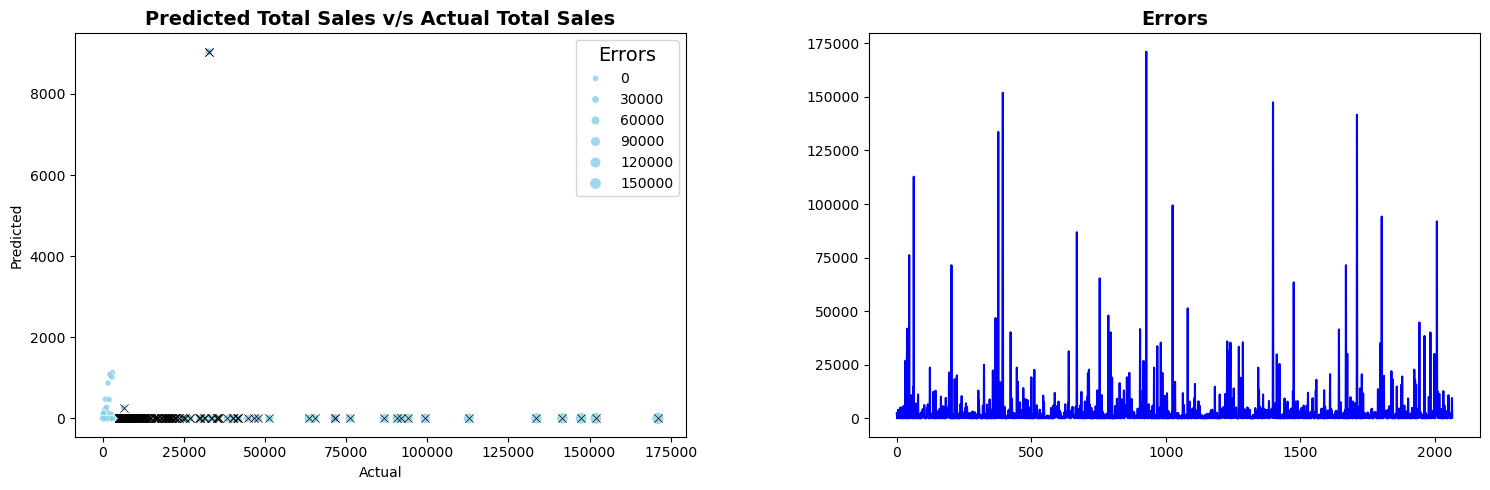

In [86]:
# actual spend in 3 months
actual =  rfm_ggd['Actual_Avg_Monetary'] * rfm_ggd['Actual_Purchases']

# predicted spend in 3 months
predicted = rfm_ggd['Predicted_Purchases'] * rfm_ggd['Predicted_Avg_Monetary']

# Error
error = actual - predicted

# create dataframe
result_df = pd.DataFrame([actual, predicted, error], index = ["Actual", "Predicted", "Error"]).T
display(result_df.head())

print(f"Average Error: {result_df['Error'].mean()}")
print(f"Mean Squared Error: {mean_squared_error(result_df['Actual'], result_df['Predicted'])}")
print(f"Root Mean Squared Error: {sqrt(mean_squared_error(result_df['Actual'], result_df['Predicted']))}")

#Predicted v/s Actual
fig, ax = plt.subplots(1, 2, figsize=(15,5))

sns.scatterplot(data=result_df, x="Actual", y="Predicted", size = "Error", color = "skyblue", alpha = 0.8, marker = 'o', ax=ax[0])
sns.scatterplot(x = result_df[result_df["Error"] > 5000]["Actual"], y=result_df[result_df["Error"] > 5000]["Predicted"], data=result_df, color = "k", marker = "x", ax=ax[0])
ax[0].set_title("Predicted Total Sales v/s Actual Total Sales", fontsize=14, fontweight='bold')
ax[0].legend(title='Errors', title_fontsize=14)

ax[1].plot(result_df["Error"], color = "b")
ax[1].set_title("Errors", fontsize=14, fontweight='bold')

plt.tight_layout()
plt.subplots_adjust(wspace=0.3, hspace=0.3)
plt.show()



In [87]:
print(rfm_ggd['Predicted_cltv'].value_counts().nlargest(2))
print("\n"+"*"*20+ "*"*20, end="\n")
print(rfm_ggd['Actual_cltv'].value_counts().nlargest(2))


Predicted_cltv
0.00    1106
0.01     169
Name: count, dtype: int64

****************************************
Actual_cltv
0.00    1866
0.01      42
Name: count, dtype: int64


Since most of the CLV scores are zero, we categorize customers into two groups:

- **Profitable** (those with predicted CLTV greater than zero)
- **Non-Profitable** (those with predicted CLTV equal to zero).


In [88]:
rfm_ggd['CLTV_label'] = rfm_ggd['Predicted_cltv'] > 0
rfm_ggd['CLTV_label'] = rfm_ggd['CLTV_label'].map({True: 'Profitable', False: 'Non-profitable'})
display(rfm_ggd.head())


,ID,Frequency,Recency,Monetary,T,Actual_Purchases,Predicted_Purchases,p_alive,p_not_alive,Actual_Avg_Monetary,Predicted_Avg_Monetary,Actual_cltv,Predicted_cltv,CLTV_label
0,5524,22,58,1617,663,34.137931,2.516544e-27,0.0000,1.0000,73.500000,73.804457,0.00,0.00,Non-profitable
1,2174,4,38,27,113,9.473684,2.179110e-02,0.0120,0.9880,6.750000,7.690625,0.01,0.29,Profitable
2,4141,20,26,776,312,69.230769,8.974190e-23,0.0000,1.0000,38.800000,39.057763,0.00,0.00,Non-profitable
3,6182,6,26,53,139,20.769231,6.844778e-05,0.0000,1.0000,8.833333,9.473611,0.00,0.29,Profitable
4,5324,14,94,422,161,13.404255,4.706186e-03,0.0011,0.9989,30.142857,30.483897,0.01,2.33,Profitable


In [89]:
# saving the results to a CSV file
rfm_ggd.to_csv(parent_path.joinpath("data", "processed", "cltv_df.csv"), index=False)
print("="*20, "CLTV dataset saved successfully.", "="*20)


==================== CLTV dataset saved successfully. ====================


In [90]:
# Compute tenure in days for further requirements
customer_seg_df['T'] = (
    (
        customer_seg_df['Dt_Customer'].max() - customer_seg_df['Dt_Customer']
    ).dt.days
    
)

# satisfy assumptions of probablistic models
customer_seg_df = customer_seg_df.query("Frequency > 0").query("Recency <= T").copy()

# Create CLV label for customer segmentation dataframe as well
customer_seg_df['CLTV_label'] = rfm_ggd['Predicted_cltv'] > 0
customer_seg_df['CLTV_label'] = customer_seg_df['CLTV_label'].map({True: 'Profitable', False: 'Non-profitable'})
display(customer_seg_df.head())


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,Age,Is_parent,Children,Day,Month,Quarter,Year,Tenure,Cluster,Recency,Monetary,Frequency,R,F,M,RFM_Score,Segment,T,CLTV_label
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,635,88,546,172,88,88,3,8,10,4,7,0,0,0,0,0,0,3,11,1,58,0,0,4,9,3,2012,28,1,58,73.500000,22,3,5,5,355,Loyal Customers,663,Non-profitable
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,11,1,6,2,1,6,2,1,1,2,5,0,0,0,0,0,0,3,11,0,61,1,2,8,3,1,2014,9,0,38,6.750000,4,4,1,1,411,Promising,113,Profitable
2,4141,1965,Graduation,Partner,71613.0,0,0,2013-08-21,426,49,127,111,21,42,1,8,2,10,4,0,0,0,0,0,0,3,11,0,50,0,0,21,8,3,2013,16,2,26,38.800000,20,4,4,4,444,Loyal Customers,312,Non-profitable
3,6182,1984,Graduation,Partner,26646.0,1,0,2014-02-10,11,4,20,10,3,5,2,2,0,4,6,0,0,0,0,0,0,3,11,0,31,1,1,10,2,1,2014,10,0,26,8.833333,6,4,2,1,421,Potential Loyalists,139,Profitable
4,5324,1981,PhD,Partner,58293.0,1,0,2014-01-19,173,43,118,46,27,15,5,5,3,6,5,0,0,0,0,0,0,3,11,0,34,1,1,19,1,1,2014,11,2,94,30.142857,14,1,3,3,133,At risk,161,Profitable


In [91]:
# saving the customer segmentation dataset with CLTV label to a CSV file
customer_seg_df.to_csv(parent_path.joinpath("data", "processed", "customer_segmentation_cltv.csv"), index=False)
print("="*20, "Customer Segmentation dataset with CLTV label saved successfully.", "="*20)


==================== Customer Segmentation dataset with CLTV label saved successfully. ====================


## **CUSTOMER VALUE SEGMENTATION USING PREDICTED CLTV**

We have calculated the Customer Lifetime Value (CLV) and shared it with the marketing team. Now, the marketing team wants to identify the **most profitable customer segments** so they can target them with more effective and optimized marketing campaigns.

Our objective is to provide the requested insights to the marketing team. To achieve this, we will perform **customer clustering based on the predicted metrics** to identify meaningful and profitable customer segments.


In [92]:
display(rfm_ggd.head())


,ID,Frequency,Recency,Monetary,T,Actual_Purchases,Predicted_Purchases,p_alive,p_not_alive,Actual_Avg_Monetary,Predicted_Avg_Monetary,Actual_cltv,Predicted_cltv,CLTV_label
0,5524,22,58,1617,663,34.137931,2.516544e-27,0.0000,1.0000,73.500000,73.804457,0.00,0.00,Non-profitable
1,2174,4,38,27,113,9.473684,2.179110e-02,0.0120,0.9880,6.750000,7.690625,0.01,0.29,Profitable
2,4141,20,26,776,312,69.230769,8.974190e-23,0.0000,1.0000,38.800000,39.057763,0.00,0.00,Non-profitable
3,6182,6,26,53,139,20.769231,6.844778e-05,0.0000,1.0000,8.833333,9.473611,0.00,0.29,Profitable
4,5324,14,94,422,161,13.404255,4.706186e-03,0.0011,0.9989,30.142857,30.483897,0.01,2.33,Profitable


In [93]:
# Selected columns for clustering : behaviour + predicted matrix

cols = ['Predicted_Purchases', 'Predicted_Avg_Monetary', 'p_alive', 'Predicted_cltv']

new_df = rfm_ggd[cols].copy()



In [94]:
new_df.corr()

,Predicted_Purchases,Predicted_Avg_Monetary,p_alive,Predicted_cltv
Predicted_Purchases,1.000000,0.024574,0.401330,0.373886
Predicted_Avg_Monetary,0.024574,1.000000,-0.099800,0.156442
p_alive,0.401330,-0.099800,1.000000,0.296235
Predicted_cltv,0.373886,0.156442,0.296235,1.000000


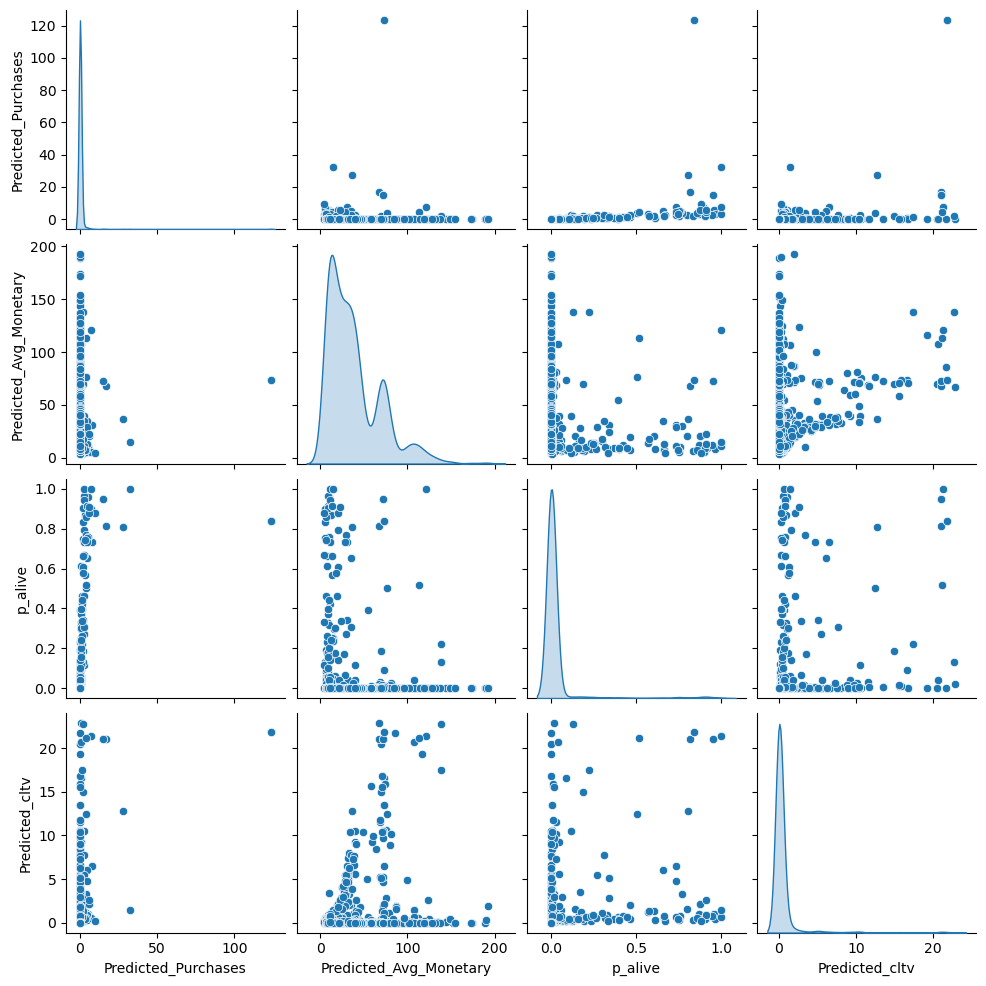

In [95]:
sns.pairplot(new_df, diag_kind='kde')
plt.show()


no_cluster,wcss,explained_variance(%),pct_explained_variance
1,1912957.340000,0.000000,0.000000
2,563244.890000,0.710000,0.710000
3,352543.930000,0.820000,0.110000
4,167973.060000,0.910000,0.100000
5,133971.980000,0.930000,0.020000
6,104118.710000,0.950000,0.020000
7,72990.100000,0.960000,0.020000
8,62472.450000,0.970000,0.010000
9,51209.930000,0.970000,0.010000
10,46349.150000,0.980000,0.000000


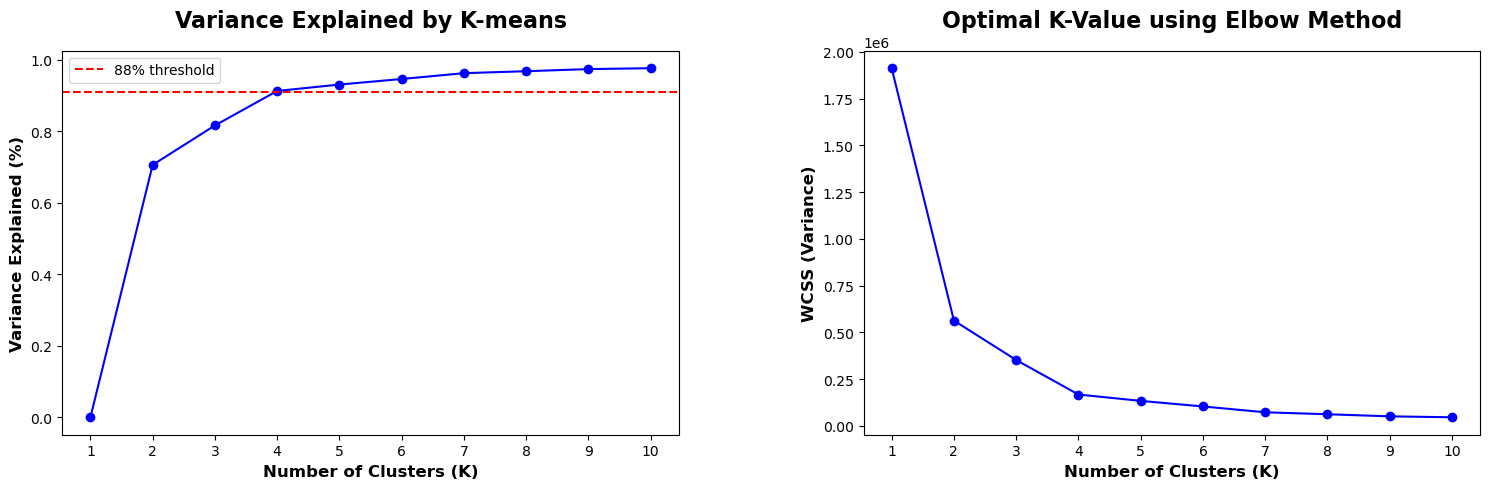

In [ ]:
from sklearn.cluster import KMeans
#  Total variance = sum of squared distances from mean
overall_mean = np.mean(np.array(new_df), axis=0)
total_variance = np.sum((np.array(new_df) - overall_mean)**2)

# KMeans Clustering with elbow method
wcss = []                           # Within-Cluster-Sum-of-Squares (WCSS)
explained_variance = []
n_cluster = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42)
    kmeans.fit(new_df)
    inertias = kmeans.inertia_
    wcss.append(inertias)
    bcss = total_variance - inertias      # between-cluster sum of squares
    explained_variance.append(bcss / total_variance)
    n_cluster.append(k)

# create dataframe
cluster_df = pd.DataFrame([], columns=['no_cluster', 'wcss', 'explained_variance(%)'])
cluster_df['no_cluster'] = n_cluster
cluster_df['wcss'] = wcss
cluster_df['explained_variance(%)'] = explained_variance
cluster_df['explained_variance(%)'] = cluster_df['explained_variance(%)'].map(lambda x: f'{x:.4f}').astype('float')
cluster_df = cluster_df.assign(pct_explained_variance=cluster_df['explained_variance(%)'].diff())
display(cluster_df.fillna(0).round(2).style.hide(axis='index').set_caption("KMeans Clustering with Elbow Method"))

# plot 
fig, ax = plt.subplots(1, 2, figsize=(15, 5))
# plot no. of clusters with variance explained
ax[0].plot(range(1, 11), explained_variance, 'bo-')
ax[0].set_xticks(range(1, 11))
ax[0].axhline(y=0.91, color='r', ls='--', label='91% threshold')
ax[0].set_xlabel('Number of Clusters (K)', fontsize=12, fontweight='bold')
ax[0].set_ylabel('Variance Explained (%)', fontsize=12, fontweight='bold')
ax[0].set_title('Variance Explained by K-means', fontsize=16, fontweight='bold', y=1.04)
ax[0].legend()

# plot no. of clusters with elbow method
ax[1].plot(range(1, 11), wcss, 'bo-')
ax[1].set_xticks(range(1, 11))
ax[1].set_xlabel('Number of Clusters (K)', fontsize=12, fontweight='bold')
ax[1].set_ylabel('WCSS (Variance)', fontsize=12, fontweight='bold')
ax[1].set_title('Optimal K-Value using Elbow Method', fontsize=16, fontweight='bold', y=1.04)

plt.tight_layout()
plt.subplots_adjust(wspace=0.3, hspace=0.3)
plt.show()


In [101]:
# will choose the smallest k that explains at least 91% of the variance, which is k=4

kmeans_clts = KMeans(n_clusters=4, init='k-means++', random_state=42)
kmeans_y = kmeans_clts.fit_predict(new_df)

# Add cluster labels to the DataFrame
kmeans_cluster_df = pd.DataFrame(new_df).copy()
kmeans_cluster_df.loc[:,'Cluster'] = kmeans_y
display(kmeans_cluster_df.round(2).head())


,Predicted_Purchases,Predicted_Avg_Monetary,p_alive,Predicted_cltv,Cluster
0,0.00,73.80,0.00,0.00,1
1,0.02,7.69,0.01,0.29,2
2,0.00,39.06,0.00,0.00,0
3,0.00,9.47,0.00,0.29,2
4,0.00,30.48,0.00,2.33,0


In [177]:
# centeroid of each cluster for each features
centers = kmeans_clts.cluster_centers_
print(f"Cluster centers:\n{centers}", end='\n\n')

# cluster label
print(f"Cluster labels: {kmeans_clts.labels_}")


Cluster centers:
[[8.77766762e-02 3.64413732e+01 7.41387283e-03 4.16965318e-01]
 [8.16641525e-01 7.12984589e+01 1.55252033e-02 1.31065041e+00]
 [2.23643429e-01 1.37701985e+01 4.76649770e-02 2.02039171e-01]
 [1.07417375e-01 1.15855319e+02 1.40220588e-02 1.01830882e+00]]

Cluster labels: [1 2 0 ... 1 0 2]


In [106]:
cluster_summary = kmeans_cluster_df.groupby('Cluster').mean()
cluster_summary['n_customers'] = kmeans_cluster_df.groupby('Cluster').size()
cluster_summary['percentage_customers'] = ((cluster_summary['n_customers']/cluster_summary['n_customers'].sum())*100).map(lambda x: f'{x:.1f}%')
display(cluster_summary.sort_values(by='Predicted_cltv', ascending=False))#.style.format("{:.2f}").set_caption("Cluster Summary"))


,Predicted_Purchases,Predicted_Avg_Monetary,p_alive,Predicted_cltv,n_customers,percentage_customers
Cluster,,,,,,
1,0.816642,71.298459,0.015525,1.310650,369,17.9%
3,0.107417,115.855319,0.014022,1.018309,136,6.6%
0,0.087777,36.441373,0.007414,0.416965,692,33.5%
2,0.223643,13.770199,0.047665,0.202039,868,42.0%


**Will name the cluster based on below table**

| Cluster | Characteristics | Suggested Name |
|---:|---|---|
| 0 | medium CLV, medium purchases | Moderate-Value Customers |
| 1 | high CLV, medium purchases | High-Value Customers |
| 2 | low CLV, low purchases | Low-value Customers |
| 3 | Very high CLV, high purchases | VIP Customers |


In [107]:
cluster_labels = {
    1: "VIP",
    3: "High-Value",
    0: "Moderate-Value",
    2: "Low-Value"
}

kmeans_cluster_df["Customer_Segment"] = kmeans_cluster_df["Cluster"].map(cluster_labels)



In [114]:
rfm_gg = rfm_ggd.merge(kmeans_cluster_df[['Cluster', 'Customer_Segment']], left_index=True, right_index=True, how='left')
display(rfm_gg.head())

,ID,Frequency,Recency,Monetary,T,Actual_Purchases,Predicted_Purchases,p_alive,p_not_alive,Actual_Avg_Monetary,Predicted_Avg_Monetary,Actual_cltv,Predicted_cltv,CLTV_label,Cluster,Customer_Segment
0,5524,22,58,1617,663,34.137931,2.516544e-27,0.0000,1.0000,73.500000,73.804457,0.00,0.00,Non-profitable,1,VIP
1,2174,4,38,27,113,9.473684,2.179110e-02,0.0120,0.9880,6.750000,7.690625,0.01,0.29,Profitable,2,Low-Value
2,4141,20,26,776,312,69.230769,8.974190e-23,0.0000,1.0000,38.800000,39.057763,0.00,0.00,Non-profitable,0,Moderate-Value
3,6182,6,26,53,139,20.769231,6.844778e-05,0.0000,1.0000,8.833333,9.473611,0.00,0.29,Profitable,2,Low-Value
4,5324,14,94,422,161,13.404255,4.706186e-03,0.0011,0.9989,30.142857,30.483897,0.01,2.33,Profitable,0,Moderate-Value


In [115]:
# saving the customer segmentation dataset with CLTV label to a CSV file
rfm_gg.to_csv(data_path.joinpath("ParetoNBD_GammaGamma_CLTV_Analysis.csv"), index=False)
print("="*20, "Customer Segmentation dataset with CLTV label saved successfully.", "="*20)


==================== Customer Segmentation dataset with CLTV label saved successfully. ====================


In [116]:
# Grouping by Customer Segment and calculating mean values for key metrics
result_df = rfm_gg.groupby('Customer_Segment').agg({
    'Predicted_Purchases': 'mean',
    'Predicted_Avg_Monetary': 'mean',
    'Predicted_cltv': 'mean',
    'p_alive': 'mean'})
result_df 


,Predicted_Purchases,Predicted_Avg_Monetary,Predicted_cltv,p_alive
Customer_Segment,,,,
High-Value,0.107417,115.855319,1.018309,0.014022
Low-Value,0.223643,13.770199,0.202039,0.047665
Moderate-Value,0.087777,36.441373,0.416965,0.007414
VIP,0.816642,71.298459,1.310650,0.015525


**1. who are the most valuable customers?**

In [117]:
display(result_df['Predicted_cltv'].sort_values(ascending=False))


Customer_Segment
VIP               1.310650
High-Value        1.018309
Moderate-Value    0.416965
Low-Value         0.202039
Name: Predicted_cltv, dtype: float64

**2. Who is likely to remain active?**

In [119]:
display(result_df['p_alive'].sort_values(ascending=False))


Customer_Segment
Low-Value         0.047665
VIP               0.015525
High-Value        0.014022
Moderate-Value    0.007414
Name: p_alive, dtype: float64

**3. Who is likely to purchase again?**

In [120]:
display(result_df['Predicted_Purchases'].sort_values(ascending=False))


Customer_Segment
VIP               0.816642
Low-Value         0.223643
High-Value        0.107417
Moderate-Value    0.087777
Name: Predicted_Purchases, dtype: float64

**4. Where should we spend our marketing budget?**

| Segment | Recommended Strategy | Marketing Priority |
|---|---|---|
| VIP Customers | Retain, reward, personalized offers |  Very High |
| High-Value Customers | Retention + upselling/cross-selling |  High |
| Moderate-value Customers | Develop into high-value customers |  Medium |
| Low-Value Customers | Low-cost campaigns / automated offers |  Low |


## **Customer Profiling**

After forming the customer segments, we analyzed their purchasing behaviors. Next, we profile each segment to understand who our most valuable customers are — the `star` group — and which customers require more attention and engagement from the store.


In [121]:
pareto_df = pd.read_csv(data_path.joinpath("ParetoNBD_GammaGamma_CLTV_Analysis.csv"))
display(pareto_df.head())


,ID,Frequency,Recency,Monetary,T,Actual_Purchases,Predicted_Purchases,p_alive,p_not_alive,Actual_Avg_Monetary,Predicted_Avg_Monetary,Actual_cltv,Predicted_cltv,CLTV_label,Cluster,Customer_Segment
0,5524,22,58,1617,663,34.137931,2.516544e-27,0.0000,1.0000,73.500000,73.804457,0.00,0.00,Non-profitable,1,VIP
1,2174,4,38,27,113,9.473684,2.179110e-02,0.0120,0.9880,6.750000,7.690625,0.01,0.29,Profitable,2,Low-Value
2,4141,20,26,776,312,69.230769,8.974190e-23,0.0000,1.0000,38.800000,39.057763,0.00,0.00,Non-profitable,0,Moderate-Value
3,6182,6,26,53,139,20.769231,6.844778e-05,0.0000,1.0000,8.833333,9.473611,0.00,0.29,Profitable,2,Low-Value
4,5324,14,94,422,161,13.404255,4.706186e-03,0.0011,0.9989,30.142857,30.483897,0.01,2.33,Profitable,0,Moderate-Value


In [122]:
# merge pareto_df with processed_df to get the complete customer information
pareto_data = pareto_df[pareto_df.columns.difference(['Frequency', 'Recency', 'Monetary', 'T'])]

# customer profile data is satisfying assumptions of probabilistic models
processed_data = customer_df.query('Frequency > 0').query("Recency <= T")
merged_df = processed_data.merge(pareto_data, how='left', on=['ID'])


In [123]:
# check missing values
merged_df.stb.missing().query('percent > 0')


,missing,total,percent


In [124]:
# saving merged file for furthur analysis
merged_df.to_csv(data_path.joinpath("processed_cltv_segmentation.csv"), index=False)
print("="*20 + "Processed dataset with CLTV segmenation file saved successfully" + "="*20)


====================Processed dataset with CLTV segmenation file saved successfully====================


#### **Overall Segment Profile**

In [125]:
segment_summary = (
    merged_df.groupby("Customer_Segment", observed=True)
    .agg(
        Customers=("ID", "count"),
        Avg_Predicted_Purchases=("Predicted_Purchases", "mean"),
        Median_Predicted_Purchases=("Predicted_Purchases", "median"),
        Avg_Predicted_Monetary=("Predicted_Avg_Monetary", "mean"),
        Median_Predicted_Monetary=("Predicted_Avg_Monetary", "median"),
        Avg_CLTV=("Predicted_cltv", "mean"),
        Median_CLTV=("Predicted_cltv", "median"),
        Avg_Historical_Spending=("Monetary", "mean"),
        Avg_Historical_Purchases=("Monetary", "mean"),
        Avg_Recency=("Recency", "mean"),
        Avg_Income=("Income", "mean"),
        Avg_Age=("Age", "mean")
    )
)

segment_summary["Customer_Percentage"] = (
    segment_summary["Customers"]
    / len(merged_df) * 100
)

profile_table = segment_summary.round(2)

display(profile_table)



,Customers,Avg_Predicted_Purchases,Median_Predicted_Purchases,Avg_Predicted_Monetary,Median_Predicted_Monetary,Avg_CLTV,Median_CLTV,Avg_Historical_Spending,Avg_Historical_Purchases,Avg_Recency,Avg_Income,Avg_Age,Customer_Percentage
Customer_Segment,,,,,,,,,,,,,
High-Value,136,0.11,0.0,115.86,111.39,1.02,0.00,1842.16,1842.16,46.90,78756.14,45.93,6.59
Low-Value,868,0.22,0.0,13.77,12.66,0.20,0.04,82.60,82.60,47.54,33766.81,43.65,42.03
Moderate-Value,692,0.09,0.0,36.44,36.31,0.42,0.00,659.54,659.54,47.00,57448.13,48.21,33.51
VIP,369,0.82,0.0,71.30,71.37,1.31,0.00,1335.47,1335.47,50.62,73403.36,48.12,17.87


#### **Demographic & Household profiling**



In [126]:
demographic_profile = (
    merged_df.groupby("Customer_Segment", observed=True)
    .agg(
        Avg_Age=("Age", "mean"),
        Median_Age=("Age", "median"),
        Avg_Income=("Income", "mean"),
        Median_Income=("Income", "median"),
        Avg_Children=("Kidhome", "mean"),
        Avg_Teenagers=("Teenhome", "mean"),
        #Avg_Total_Children=("TotalChildren", "mean")
    )
)

display(demographic_profile.round(2))


,Avg_Age,Median_Age,Avg_Income,Median_Income,Avg_Children,Avg_Teenagers
Customer_Segment,,,,,,
High-Value,45.93,45.0,78756.14,79998.5,0.06,0.15
Low-Value,43.65,42.0,33766.81,33575.0,0.80,0.45
Moderate-Value,48.21,48.0,57448.13,57589.5,0.26,0.73
VIP,48.12,49.0,73403.36,72460.0,0.07,0.34


#### **Education Profile**

Education,Graduation,PhD,PostGraduation,UnderGraduation
Customer_Segment,,,,
High-Value,48.53,29.41,22.06,0.00
Low-Value,48.62,18.43,27.42,5.53
Moderate-Value,51.45,21.82,26.30,0.43
VIP,52.85,24.12,23.04,0.00


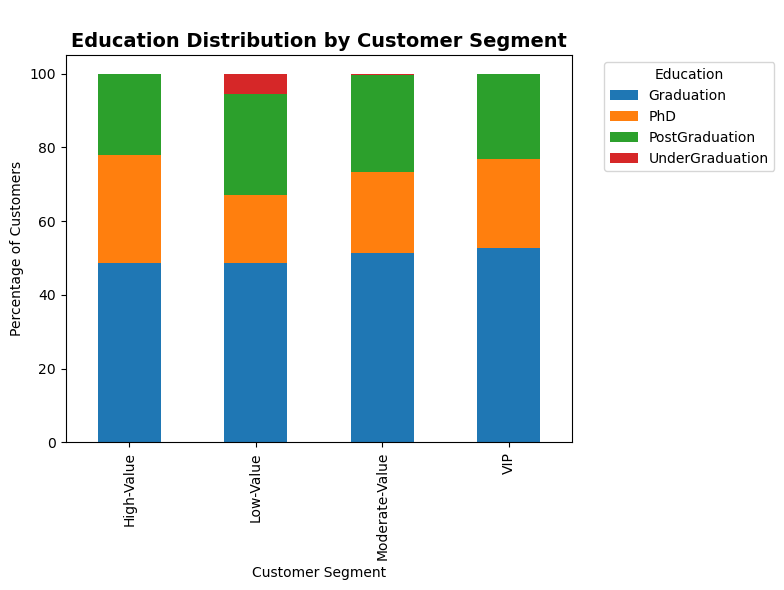

In [127]:
education_profile = pd.crosstab(
    merged_df["Customer_Segment"],
    merged_df["Education"],
    normalize="index"
) * 100

display(education_profile.round(2))

# Visualize

education_profile.plot(
    kind="bar",
    stacked=True,
    figsize=(8, 6)
)

plt.title("\nEducation Distribution by Customer Segment", fontsize=14, fontweight='bold')
plt.ylabel("Percentage of Customers")
plt.xlabel("Customer Segment")
plt.legend(title="Education", bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()


#### **Marital-Status Profile**

Marital_Status,Partner,Single
Customer_Segment,,
High-Value,58.82,41.18
Low-Value,64.40,35.60
Moderate-Value,65.32,34.68
VIP,63.14,36.86


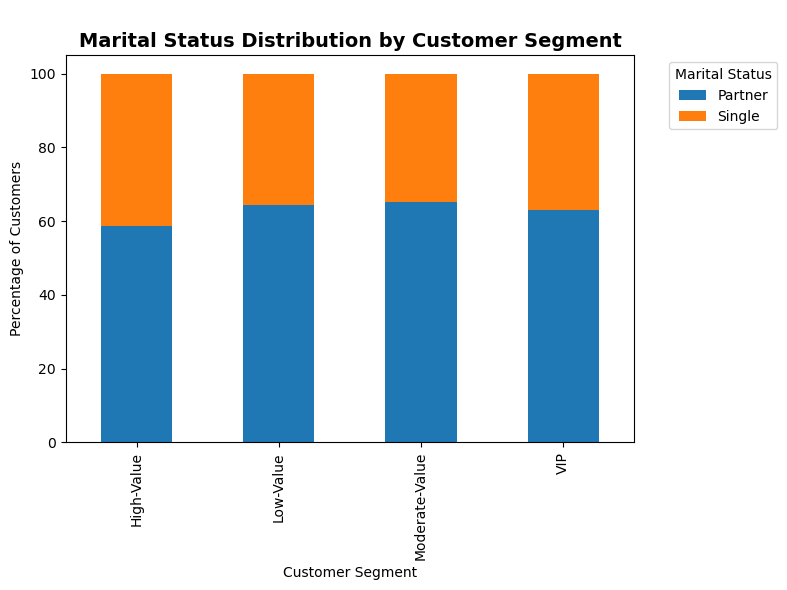

In [128]:
marital_profile = pd.crosstab(
    merged_df["Customer_Segment"],
    merged_df["Marital_Status"],
    normalize="index"
) * 100

display(marital_profile.round(2))

# Visualize
marital_profile.plot(
    kind="bar",
    stacked=True,
    figsize=(8, 6)
)

plt.title("\nMarital Status Distribution by Customer Segment", fontsize=14, fontweight='bold')
plt.ylabel("Percentage of Customers")
plt.xlabel("Customer Segment")
plt.legend(
    title="Marital Status",
    bbox_to_anchor=(1.05, 1)
)

plt.tight_layout()
plt.show()


#### **Product preference profiling**

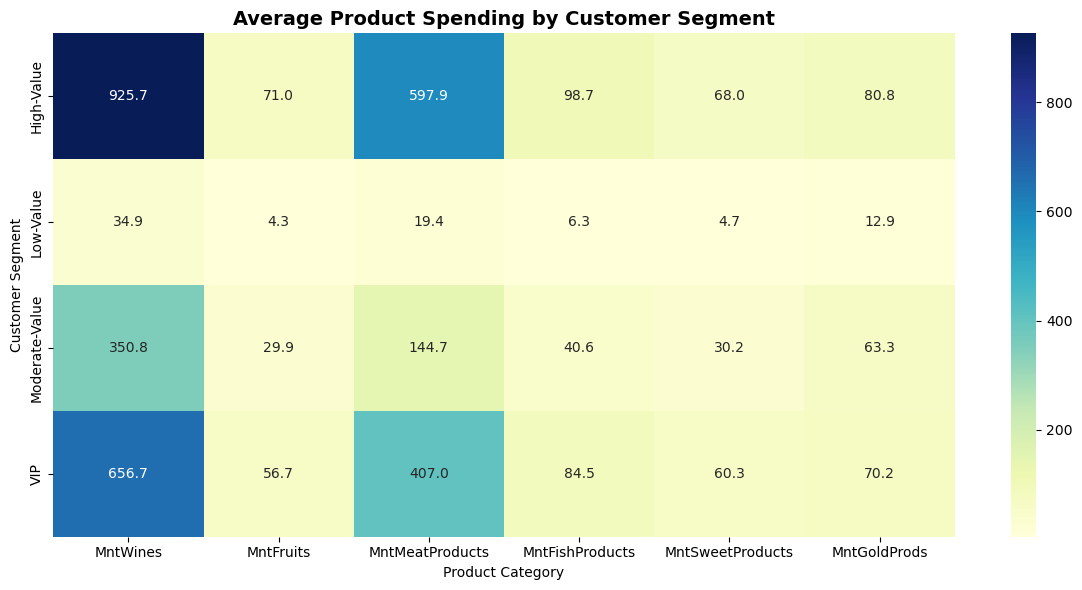

In [129]:
product_cols = [
    "MntWines",
    "MntFruits",
    "MntMeatProducts",
    "MntFishProducts",
    "MntSweetProducts",
    "MntGoldProds"
]

product_profile = (
    merged_df.groupby("Customer_Segment", observed=True)[product_cols]
    .mean()
)

(product_profile.round(2))

# plot heatmap
plt.figure(figsize=(12, 6))

sns.heatmap(
    product_profile,
    annot=True,
    fmt=".1f",
    cmap="YlGnBu"
)

plt.title("Average Product Spending by Customer Segment", fontsize=14, fontweight='bold')
plt.xlabel("Product Category")
plt.ylabel("Customer Segment")

plt.tight_layout()
plt.show()


#### **Product spending as a percentage of total spending**

Absolute spending is strongly affected by CLTV/value, so also look at product mix.


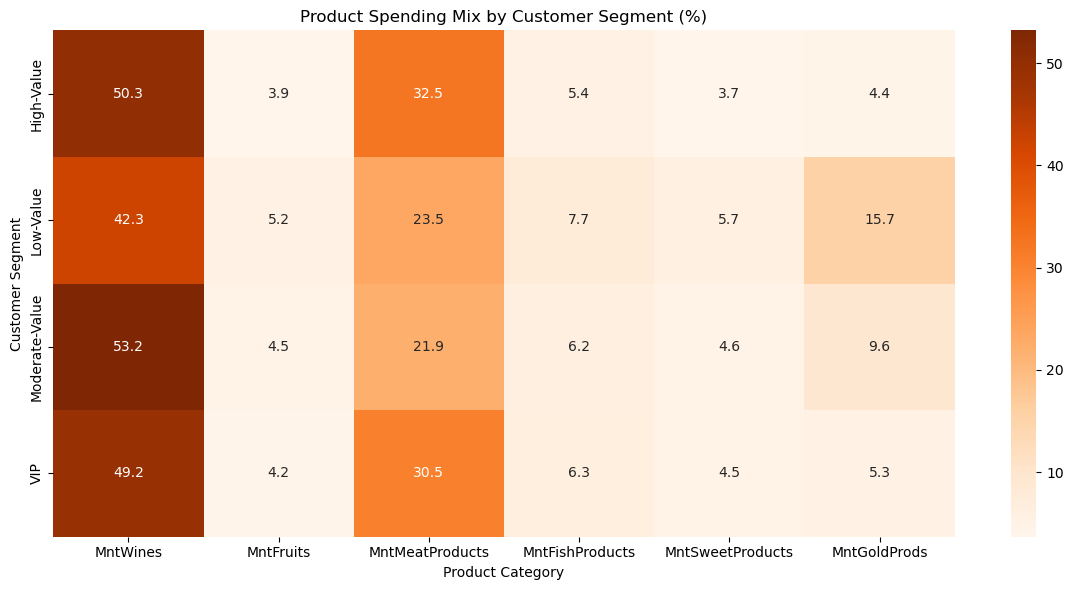

**Insight :VIP customers allocate a larger share of spending to fruit and meat products.**

In [130]:
product_mix = product_profile.div(
    product_profile.sum(axis='columns'),
    axis='index'
) * 100

product_mix.round(2)

# Plot Heatmap
plt.figure(figsize=(12, 6))

sns.heatmap(
    product_mix,
    annot=True,
    fmt=".1f",
    cmap="Oranges"
)

plt.title("Product Spending Mix by Customer Segment (%)")
plt.xlabel("Product Category")
plt.ylabel("Customer Segment")

plt.tight_layout()
plt.show()

display_md("**Insight :VIP customers allocate a larger share of spending to fruit and meat products.**")


#### **Channel behavior**

,NumWebPurchases,NumCatalogPurchases,NumStorePurchases
Customer_Segment,,,
High-Value,4.46,5.25,6.75
Low-Value,2.04,0.48,3.13
Moderate-Value,6.17,3.37,7.93
VIP,5.17,5.73,8.03


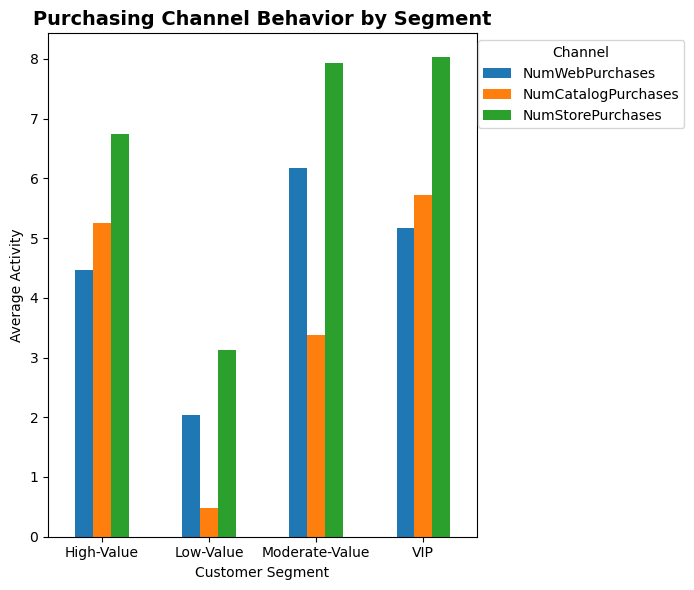

In [147]:
channel_cols = [
    "NumWebPurchases",
    "NumCatalogPurchases",
    "NumStorePurchases"
    #"NumWebVisitsMonth"
]

channel_profile = (
    merged_df.groupby("Customer_Segment", observed=True)[channel_cols]
    .mean()
)

display(channel_profile.round(2))

# Plot
channel_profile.plot(
    kind="bar",
    #stacked=True,
    figsize=(8, 6)
)

plt.title("Purchasing Channel Behavior by Segment", fontsize=14, fontweight='bold')
plt.ylabel("Average Activity")
plt.xlabel("Customer Segment")

plt.xticks(rotation=0)
plt.legend(
    title="Channel",
    bbox_to_anchor=(1.5, 1)
)

plt.tight_layout()
plt.show()


#### **Calculate channel preference**

A better measure is the percentage of purchases occurring through each channel.

,NumWebPurchases,NumCatalogPurchases,NumStorePurchases
Customer_Segment,,,
High-Value,27.11,31.89,41.00
Low-Value,36.14,8.47,55.39
Moderate-Value,35.33,19.30,45.37
VIP,27.30,30.27,42.43


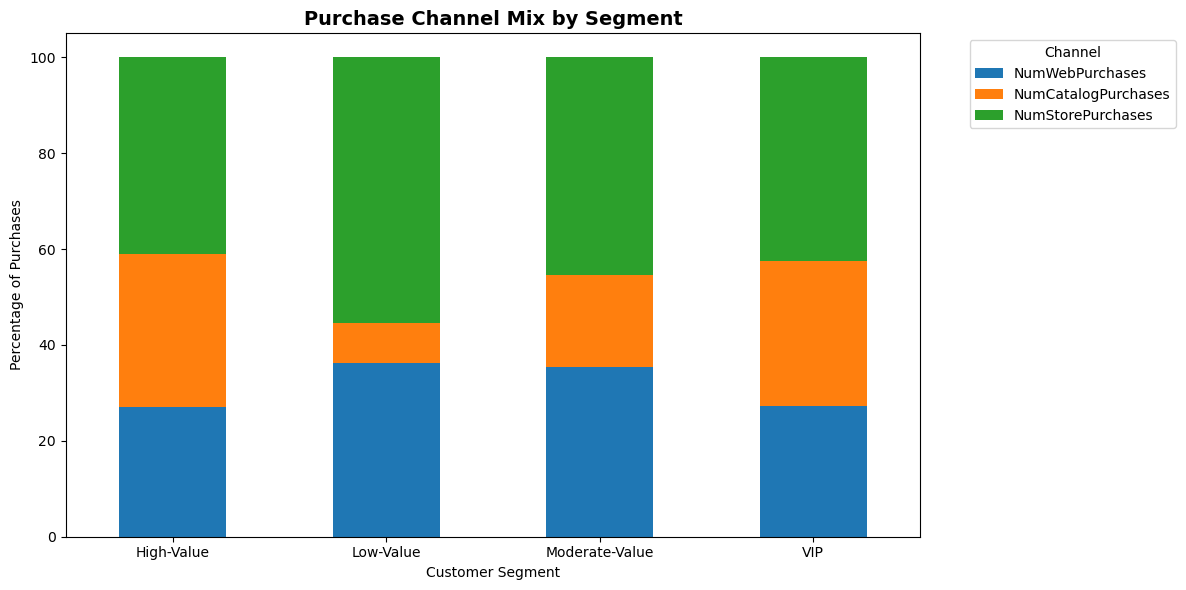

In [148]:
channel_purchase_cols = [
    "NumWebPurchases",
    "NumCatalogPurchases",
    "NumStorePurchases"
]

channel_mix = (
    merged_df.groupby("Customer_Segment", observed=True)[channel_purchase_cols]
    .sum()
)

channel_mix_pct = (
    channel_mix.div(
        channel_mix.sum(axis='columns'),
        axis='index'
    ) * 100
)

display(channel_mix_pct.round(2))

# Plot 
channel_mix_pct.plot(
    kind="bar",
    stacked=True,
    figsize=(12, 6)
)

plt.title("Purchase Channel Mix by Segment", fontsize=14, fontweight='bold')
plt.ylabel("Percentage of Purchases")
plt.xlabel("Customer Segment")

plt.xticks(rotation=0)
plt.legend(
    title="Channel",
    bbox_to_anchor=(1.05, 1)
)

plt.tight_layout()
plt.show()


#### **Engagement profiling**

In [149]:
engagement_cols = [
    "Recency",
    "NumWebVisitsMonth",
    "NumDealsPurchases",
    "Complain"
]

engagement_profile = (
    merged_df.groupby("Customer_Segment", observed=True)[engagement_cols]
    .mean()
)

display(engagement_profile.round(2))

display_md("**Insight : VIP customers purchased more recently which implies they are more engaged customers.**")


,Recency,NumWebVisitsMonth,NumDealsPurchases,Complain
Customer_Segment,,,,
High-Value,46.90,3.49,1.23,0.00
Low-Value,47.54,6.46,1.98,0.01
Moderate-Value,47.00,5.38,3.24,0.01
VIP,50.62,3.61,1.97,0.00


**Insight : VIP customers purchased more recently which implies they are more engaged customers.**

#### **Campaign-response profiling**

In [150]:
campaign_cols = [
    "AcceptedCmp1",
    "AcceptedCmp2",
    "AcceptedCmp3",
    "AcceptedCmp4",
    "AcceptedCmp5",
    "Response"
]

campaign_profile = (
    merged_df.groupby("Customer_Segment", observed=True)[campaign_cols]
    .mean() * 100
)

display(campaign_profile.round(2))

# NOTE: Because these are binary variables, the mean × 100 gives you the percentage of customers who responded.



,AcceptedCmp1,AcceptedCmp2,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,Response
Customer_Segment,,,,,,
High-Value,30.15,6.62,10.29,26.47,47.79,49.26
Low-Value,0.23,0.35,7.03,1.15,0.12,9.45
Moderate-Value,4.19,1.01,7.80,7.95,3.18,13.58
VIP,15.18,2.71,7.05,14.36,17.62,23.58


#### **Overall campaign response**

Customer_Segment
Low-Value          9.45
Moderate-Value    13.58
VIP               23.58
High-Value        49.26
Name: Response, dtype: float64

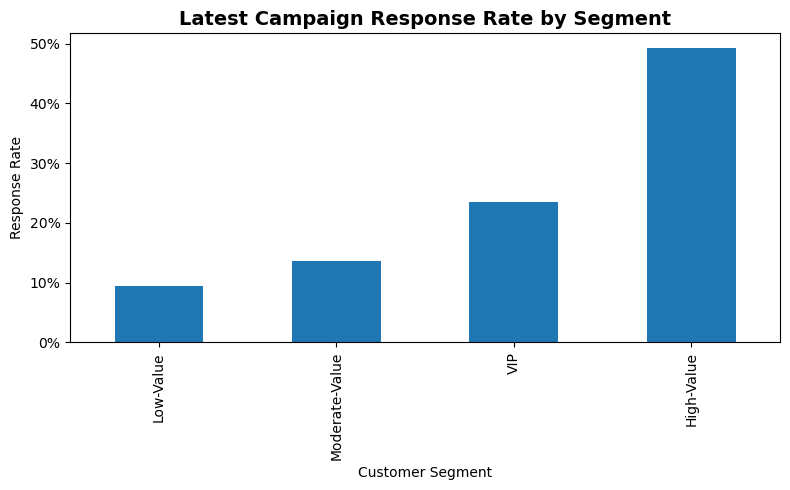

In [160]:
response_profile = (
    merged_df.groupby("Customer_Segment", observed=True)["Response"]
    .mean() * 100
)

display(response_profile.round(2).sort_values())

plt.figure(figsize=(8, 5))

response_profile.sort_values().plot(kind='bar')

plt.title("Latest Campaign Response Rate by Segment", fontsize=14, fontweight='bold')
plt.ylabel("Response Rate")
plt.xlabel("Customer Segment")

plt.gca().yaxis.set_major_formatter(
    plt.FuncFormatter(lambda y, _: f"{y:.0f}%")
)

plt.tight_layout()
plt.show()


#### **Standardized cluster profile**



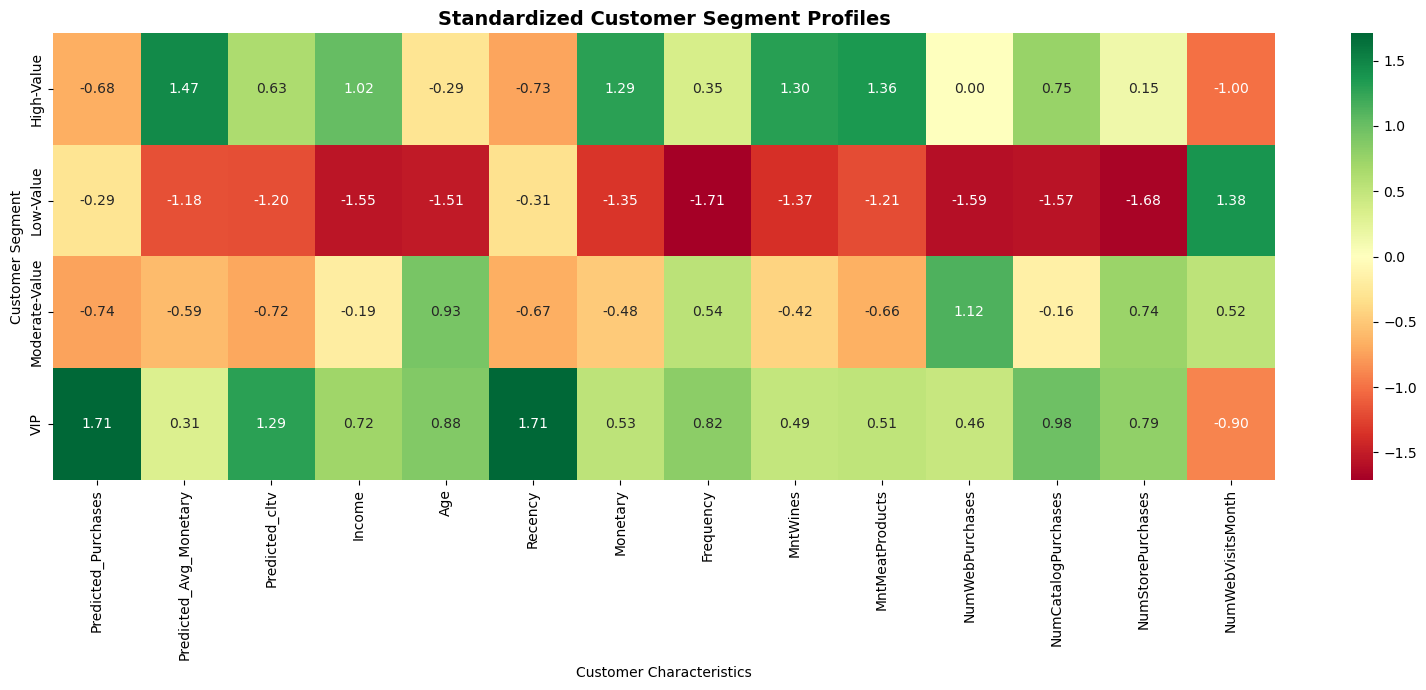

In [161]:
from sklearn.preprocessing import StandardScaler
profile_variables = [
    "Predicted_Purchases",
    "Predicted_Avg_Monetary",
    "Predicted_cltv",
    "Income",
    "Age",
    "Recency",
    "Monetary",
    "Frequency",
    "MntWines",
    "MntMeatProducts",
    "NumWebPurchases",
    "NumCatalogPurchases",
    "NumStorePurchases",
    "NumWebVisitsMonth"
]

profile_means = (
    merged_df.groupby("Customer_Segment", observed=True)[profile_variables]
    .mean()
)

# Standardize variables across segments
scaler = StandardScaler()

profile_scaled = pd.DataFrame(
    scaler.fit_transform(profile_means),
    index=profile_means.index,
    columns=profile_means.columns
)

(profile_scaled.round(2))

# visualize
plt.figure(figsize=(16, 7))

sns.heatmap(
    profile_scaled,
    annot=True,
    fmt=".2f",
    cmap="RdYlGn",
    center=0
)

plt.title("Standardized Customer Segment Profiles", fontsize=14, fontweight='bold')
plt.xlabel("Customer Characteristics")
plt.ylabel("Customer Segment")

plt.tight_layout()
plt.show()

## NOTE : This shows which characteristics are above or below the overall segment average.



#### **Statistical testing — numerical variables**
Now test whether your clusters are actually different.

We'll use the Kruskal–Wallis test, which is a good choice when customer variables aren't normally distributed.

In [162]:
from scipy.stats import kruskal, chi2_contingency
numeric_test_cols = [
    "Predicted_Purchases",
    "Predicted_Avg_Monetary",
    "Predicted_cltv",
    "Income",
    "Age",
    "Recency",
    "Monetary",
    "Frequency",
    "MntWines",
    "MntMeatProducts",
    "MntFishProducts",
    "MntFruits",
    "MntSweetProducts",
    "MntGoldProds",
    "NumWebPurchases",
    "NumCatalogPurchases",
    "NumStorePurchases",
    "NumWebVisitsMonth"
]

results = []

for col in numeric_test_cols:

    groups = [
        group[col].dropna()
        for _, group in merged_df.groupby("Customer_Segment", observed=True)
    ]

    stat, p_value = kruskal(*groups)

    results.append({
        "Variable": col,
        "H_Statistic": stat,
        "P_Value": p_value,
        "Significant": "Yes" if p_value < 0.05 else "No"
    })

kruskal_results = pd.DataFrame(results)

kruskal_results.sort_values("P_Value")

# You can then identify variables that significantly differentiate your segments:

significant_variables = kruskal_results[
    kruskal_results["P_Value"] < 0.05
]

display(significant_variables)


,Variable,H_Statistic,P_Value,Significant
0,Predicted_Purchases,792.944053,1.467218e-171,Yes
1,Predicted_Avg_Monetary,1820.677903,0.000000e+00,Yes
2,Predicted_cltv,399.947281,2.272871e-86,Yes
3,Income,1368.273551,2.256925e-296,Yes
4,Age,78.048758,8.044735e-17,Yes
6,Monetary,1745.112194,0.000000e+00,Yes
7,Frequency,1445.904795,0.000000e+00,Yes
8,MntWines,1558.904154,0.000000e+00,Yes
9,MntMeatProducts,1580.093102,0.000000e+00,Yes
10,MntFishProducts,841.614287,4.081233e-182,Yes


#### **Statistical testing — categorical variables**

For education and marital status:



In [163]:
categorical_cols = [
    "Education",
    "Marital_Status"
]

chi_results = []

for col in categorical_cols:

    contingency_table = pd.crosstab(
        merged_df["Customer_Segment"],
        merged_df[col]
    )

    chi2, p, dof, expected = chi2_contingency(
        contingency_table
    )

    chi_results.append({
        "Variable": col,
        "Chi2": chi2,
        "P_Value": p,
        "Significant": "Yes" if p < 0.05 else "No"
    })

chi_results = pd.DataFrame(chi_results)

display(chi_results)


,Variable,Chi2,P_Value,Significant
0,Education,70.003429,1.520338e-11,Yes
1,Marital_Status,2.272501,5.178094e-01,No


#### **Find the defining characteristics of each segment**
This is where you turn the analysis into actual profiling.

Calculate the overall mean:



In [164]:
# Overall population means
overall_means = merged_df[profile_variables].mean()

# Segment means
segment_means = (
    merged_df.groupby("Customer_Segment", observed=True)[profile_variables]
    .mean()
)

# Relative profile: segment mean / overall mean
relative_profile = segment_means / overall_means

# Convert to percentage difference
relative_profile_pct = (relative_profile - 1) * 100

# Round for presentation
display(relative_profile_pct.round(1).style.highlight_max(axis='index'))
display_md("**VIP customers spend approximately 65% more on wine than the overall customer population.**")


,Predicted_Purchases,Predicted_Avg_Monetary,Predicted_cltv,Income,Age,Recency,Monetary,Frequency,MntWines,MntMeatProducts,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth
Customer_Segment,,,,,,,,,,,,,,
High-Value,-61.100000,201.900000,93.600000,52.200000,-0.400000,-2.000000,199.200000,29.700000,198.100000,254.300000,7.700000,94.400000,15.400000,-35.400000
Low-Value,-19.100000,-64.100000,-61.600000,-34.700000,-5.400000,-0.700000,-86.600000,-55.500000,-88.800000,-88.500000,-50.800000,-82.300000,-46.600000,19.700000
Moderate-Value,-68.200000,-5.000000,-20.700000,11.000000,4.500000,-1.800000,7.100000,37.700000,13.000000,-14.300000,49.000000,24.900000,35.500000,-0.200000
VIP,195.400000,85.800000,149.200000,41.800000,4.300000,5.800000,116.900000,49.000000,111.500000,141.200000,24.700000,112.000000,37.200000,-33.100000


**VIP customers spend approximately 65% more on wine than the overall customer population.**

#### **Automatically find the top characteristics of each segment**

In [165]:
for segment in merged_df['Customer_Segment'].unique():

    print("\n" + "="*60)
    print(segment)
    print("="*60)

    profile = relative_profile_pct.loc[segment]

    print(
        profile
        .sort_values(ascending=False)
        .head(5)
        .round(1)
    )

    print("\nLowest characteristics:")

    print(
        profile
        .sort_values()
        .head(5)
        .round(1)
    )




VIP
Predicted_Purchases    195.4
Predicted_cltv         149.2
MntMeatProducts        141.2
Monetary               116.9
NumCatalogPurchases    112.0
Name: VIP, dtype: float64

Lowest characteristics:
NumWebVisitsMonth   -33.1
Age                   4.3
Recency               5.8
NumWebPurchases      24.7
NumStorePurchases    37.2
Name: VIP, dtype: float64

Low-Value
NumWebVisitsMonth      19.7
Recency                -0.7
Age                    -5.4
Predicted_Purchases   -19.1
Income                -34.7
Name: Low-Value, dtype: float64

Lowest characteristics:
MntWines                 -88.8
MntMeatProducts          -88.5
Monetary                 -86.6
NumCatalogPurchases      -82.3
Predicted_Avg_Monetary   -64.1
Name: Low-Value, dtype: float64

Moderate-Value
NumWebPurchases        49.0
Frequency              37.7
NumStorePurchases      35.5
NumCatalogPurchases    24.9
MntWines               13.0
Name: Moderate-Value, dtype: float64

Lowest characteristics:
Predicted_Purchases      -68.2

#### **Customer segment size visualization**

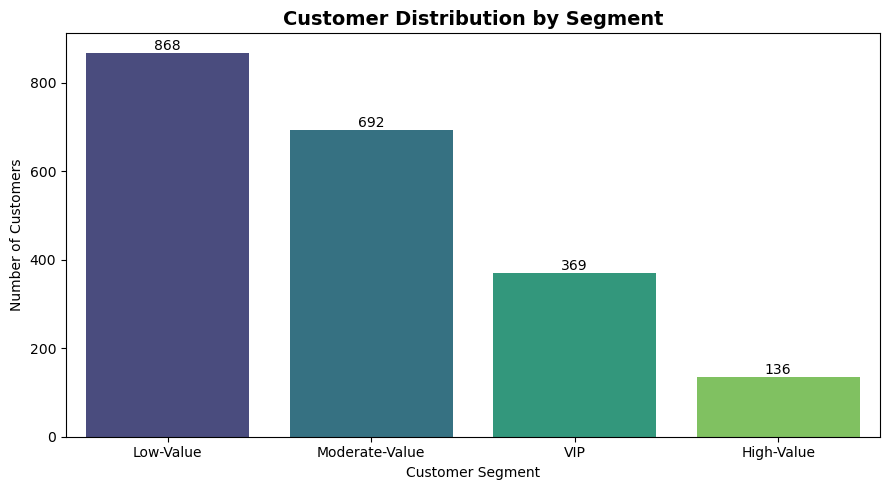

In [166]:

segment_counts = (
    merged_df["Customer_Segment"]
    .value_counts()
    #.reindex(segment_order)
)

plt.figure(figsize=(9, 5))

ax = sns.barplot(
    x=segment_counts.index,
    y=segment_counts.values,
    palette="viridis"
)

plt.title("Customer Distribution by Segment", fontsize=14, fontweight='bold')
plt.xlabel("Customer Segment")
plt.ylabel("Number of Customers")

for i, value in enumerate(segment_counts.values):
    ax.text(
        i,
        value,
        f"{value:,}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()


#### **CLTV Distribution**

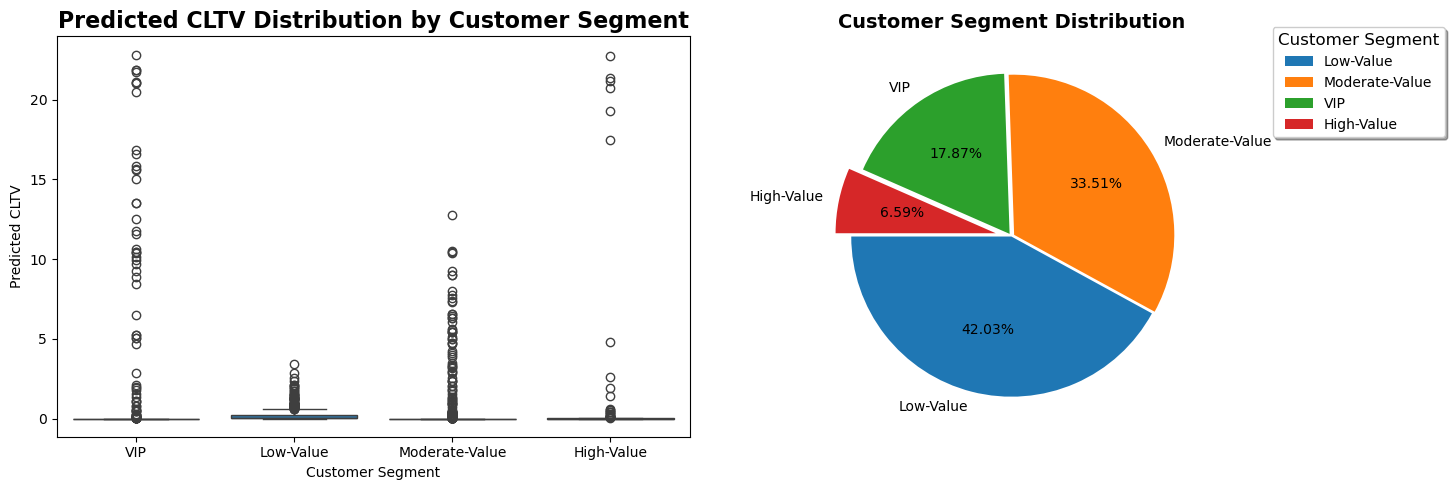

In [173]:
#Don't look at average CLTV

fig, ax = plt.subplots(ncols=2, figsize=(15, 5))

# Box plot
sns.boxplot(
    data=merged_df,
    x="Customer_Segment",
    y="Predicted_cltv",
    ax=ax[0]
)

ax[0].set_title("Predicted CLTV Distribution by Customer Segment", fontdict={'size':16, 'weight':'bold'})
ax[0].set_xlabel("Customer Segment")
ax[0].set_ylabel("Predicted CLTV")

# Pie Chart
ax[1].pie(
    kmeans_cluster_df["Customer_Segment"].value_counts(), 
    labels = kmeans_cluster_df["Customer_Segment"].value_counts().index, 
    startangle = 180, 
    explode = [0.0,0.02,0.02,0.1],
    autopct = "%1.2f%%"
)

ax[1].set_title("Customer Segment Distribution", fontsize=14, fontweight='bold')
ax[1].legend(loc='upper right', title="Customer Segment", title_fontsize=12, fontsize=10, bbox_to_anchor=(1.6, 1.04), shadow=True)


plt.tight_layout()
plt.subplots_adjust(hspace=0.01)
plt.show()

#This lets you see whether your segments are genuinely separated or whether there is substantial overlap.



#### **CLTV vs predicted purchases**

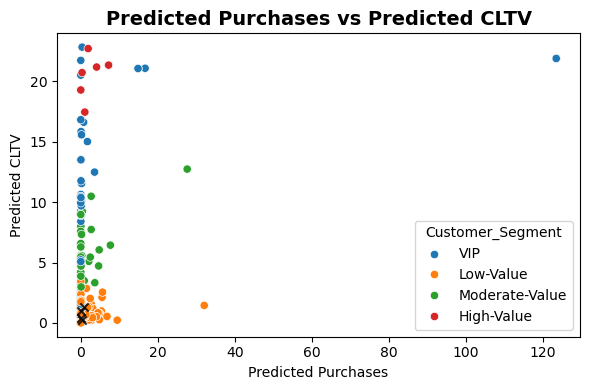

In [178]:
plt.figure(figsize=(6, 4))

sns.scatterplot(
    data=merged_df,
    x="Predicted_Purchases",
    y="Predicted_cltv",
    hue="Customer_Segment"
)
plt.scatter(centers[:, 0], centers[:, 3], marker = "x", color = "k", alpha = 0.8)

plt.title("Predicted Purchases vs Predicted CLTV", fontdict={'size':14, 'weight':'bold'})
plt.xlabel("Predicted Purchases")
plt.ylabel("Predicted CLTV")

plt.tight_layout()
plt.show()


#### **CLTV vs predicted monetary value**

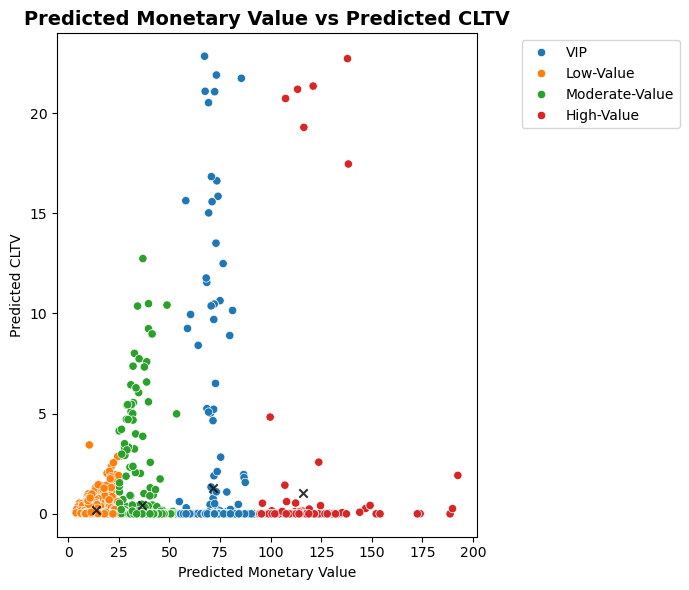

In [180]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=merged_df,
    x="Predicted_Avg_Monetary",
    y="Predicted_cltv",
    hue="Customer_Segment"
)

plt.scatter(centers[:, 1], centers[:, 3], marker = "x", color = "k", alpha = 0.8)

plt.title("Predicted Monetary Value vs Predicted CLTV", fontdict={'size':14, 'weight':'bold'})
plt.xlabel("Predicted Monetary Value")
plt.ylabel("Predicted CLTV")
plt.legend(loc='upper right',bbox_to_anchor=(1.5, 1))

plt.tight_layout()
plt.show()


#### **Final business profile table**

In [185]:
final_profile = (
    merged_df.groupby("Customer_Segment", observed=True)
    .agg(
        Customers=("ID", "count"),
        Customer_Percentage=("ID", lambda x: len(x) / len(merged_df) * 100),

        Avg_CLTV=("Predicted_cltv", "mean"),
        Median_CLTV=("Predicted_cltv", "median"),

        Avg_Predicted_Purchases=("Predicted_Purchases", "mean"),
        Avg_Predicted_Monetary=("Predicted_Avg_Monetary", "mean"),

        Avg_Income=("Income", "mean"),
        Avg_Age=("Age", "mean"),

        Avg_Recency=("Recency", "mean"),
        Avg_Total_Spending=("Monetary", "mean"),
        Avg_Total_Purchases=("Frequency", "mean"),

        Avg_Web_Purchases=("NumWebPurchases", "mean"),
        Avg_Catalog_Purchases=("NumCatalogPurchases", "mean"),
        Avg_Store_Purchases=("NumStorePurchases", "mean"),

        Campaign_Response=("Response", "mean")
    )
)

final_profile["Campaign_Response"] *= 100

display(final_profile.round(2).style.highlight_max(axis='index', color='lightskyblue'))


,Customers,Customer_Percentage,Avg_CLTV,Median_CLTV,Avg_Predicted_Purchases,Avg_Predicted_Monetary,Avg_Income,Avg_Age,Avg_Recency,Avg_Total_Spending,Avg_Total_Purchases,Avg_Web_Purchases,Avg_Catalog_Purchases,Avg_Store_Purchases,Campaign_Response
Customer_Segment,,,,,,,,,,,,,,,
High-Value,136,6.590000,1.020000,0.000000,0.110000,115.860000,78756.140000,45.930000,46.900000,1842.160000,16.460000,4.460000,5.250000,6.750000,49.260000
Low-Value,868,42.030000,0.200000,0.040000,0.220000,13.770000,33766.810000,43.650000,47.540000,82.600000,5.650000,2.040000,0.480000,3.130000,9.450000
Moderate-Value,692,33.510000,0.420000,0.000000,0.090000,36.440000,57448.130000,48.210000,47.000000,659.540000,17.480000,6.170000,3.370000,7.930000,13.580000
VIP,369,17.870000,1.310000,0.000000,0.820000,71.300000,73403.360000,48.120000,50.620000,1335.470000,18.920000,5.170000,5.730000,8.030000,23.580000


### **Marketing Recommendations**

In [146]:
marketing_strategy = {
    "VIP": {
        "Objective": "Retain and maximize customer lifetime value",
        "Strategy": "Personalized premium offers, loyalty rewards, early access, cross-selling",
        "Priority": "Very High"
    },

    "High-Value": {
        "Objective": "Increase customer value and move customers toward VIP",
        "Strategy": "Upselling, cross-selling, loyalty incentives, personalized recommendations",
        "Priority": "High"
    },

    "Moderate-Value": {
        "Objective": "Develop customers into higher-value segments",
        "Strategy": "Product bundles, targeted promotions, cross-selling and engagement campaigns",
        "Priority": "Medium"
    },

    "Low-Value": {
        "Objective": "Reactivate customers at low acquisition/marketing cost",
        "Strategy": "Automated reactivation campaigns, selective discounts and low-cost communication",
        "Priority": "Low"
    }
}

strategy_table = pd.DataFrame(marketing_strategy).T

strategy_table


,Objective,Strategy,Priority
VIP,Retain and maximize customer lifetime value,"Personalized premium offers, loyalty rewards, ...",Very High
High-Value,Increase customer value and move customers tow...,"Upselling, cross-selling, loyalty incentives, ...",High
Moderate-Value,Develop customers into higher-value segments,"Product bundles, targeted promotions, cross-se...",Medium
Low-Value,Reactivate customers at low acquisition/market...,"Automated reactivation campaigns, selective di...",Low


### **Project Highlights**


| Segment | Value | Customer Characteristics | Buying Behavior | Engagement | Strategy |
|---|---|---|---|---|---|
| **VIP** | Highest CLTV | Affluent / distinctive demographic profile | Highest CLTV and purchases | Strongest engagement | Retain, personalize, and offer premium products |
| **High-Value** | High CLTV | Similar to VIP but with lower overall value | Strong spending activity | Good engagement | Upsell, cross-sell, and migrate toward VIP |
| **Moderate-Value** | Medium CLTV | Middle-tier customer profile | Moderate spending and purchasing activity | Moderate engagement | Develop, cross-sell, and increase purchase frequency |
| **Low-Value** | Lowest CLTV | Lower-value customer profile | Low purchase activity and spending | Weak engagement | Reactivate selectively using low-cost targeted campaigns |



### **Overall Strategy**

> **Prioritize VIP and High-Value Customers for retention and revenue growth, develop Moderate-Value Customers into higher-value segments, and manage Low-Value Customers through cost-effective automated marketing.**



**SEGMENT CHARACTERISTICS RECOMMENDATIONS ACTION REVENUE IMPACT**

| Segment | Characteristics | Recommended Actions | Revenue Impact |
|---|---|---|---|
| 🌟 **VIP (Tier 1)** | High Frequency + High Monetary + Recent Activity | Premium support, exclusive early access, personalized concierge | 40–50% revenue |
| 💎 **Core (Tier 2)** | Medium Frequency + Medium Monetary + Consistent | Loyalty rewards, tiered discounts, targeted upsells | 30–35% revenue |
| ⚠️ **At-Risk (Tier 3)** | Medium-High Frequency + Declining Recency + Churn Probability >30% | Win-back campaigns, special incentives, re-engagement emails | Prevent 15–20% churn |
| 🔄 **Dormant (Tier 4)** | Low Frequency + High Recency + Inactivity Probability >50% | Reactivation campaigns, "we miss you" offers, feedback requests | Recover 5–10% |

**CUSTOMER BEHAVIOUR INSIGHTS FROM RFM ANALYSIS**

| RFM Metric | Segment | Customer Behavior | Recommended Action |
|---|---|---|---|
| **Recency (R)** | Recent buyers (0–30 days) | High engagement | Maintain momentum with personalized offers |
| **Recency (R)** | Medium (31–90 days) | Moderate engagement | Monitor closely with gentle re-engagement |
| **Recency (R)** | Inactive (>90 days) | Low/no recent activity | Aggressive win-back campaigns |
| **Frequency (F)** | Top 20% (20+ purchases) | Highly loyal customers | VIP treatment and subscription opportunities |
| **Frequency (F)** | Mid-tier (8–15 purchases) | Regular repeat buyers | Upsell complementary products |
| **Frequency (F)** | Low engagement (1–5 purchases) | Limited repeat purchasing | Educate on product variety |
| **Monetary (M)** | High spenders (>$1,000) | High-value customers | Premium tier and exclusive benefits |
| **Monetary (M)** | Mid-tier ($300–$1,000) | Moderate-value customers | Cross-sell opportunities |
| **Monetary (M)** | Low-value (<$300) | Lower transaction value | Volume strategy and bundle offers |


**CHURN RISK & SURVIVAL PREDICTION MODEL OUTPUT TO MONITOR**

| Category | Risk Level / Indicator | Criteria | Recommended Action |
|---|---|---|---|
| **Probability of Survival (BG/NBD)** | 🟢 **Low Risk – RETAIN** | P(Active) > 80% | Retain with loyalty benefits and personalized offers |
| **Probability of Survival (BG/NBD)** | 🟡 **Medium Risk – ENGAGE** | P(Active) 50–80% | Monitor and run targeted engagement campaigns |
| **Probability of Survival (BG/NBD)** | 🔴 **High Risk – INTERVENE** | P(Active) < 50% | Launch proactive retention and win-back campaigns |
| **Churn Probability (Pareto/NBD)** | ⚠️ **Recency Increasing** | Last purchase getting older | Trigger re-engagement campaign |
| **Churn Probability (Pareto/NBD)** | ⚠️ **Frequency Plateauing** | No repeat purchases | Encourage repeat purchases with targeted offers |
| **Churn Probability (Pareto/NBD)** | ⚠️ **Monetary Declining** | Spending less per transaction | Use cross-sell, upsell, and value-based offers |
| **Actionable Alert** | 🚨 **Immediate Intervention** | Recency > 60 days **AND** Frequency < 5 **AND** Churn Probability > 40% | Execute immediate retention campaign |
| **Retention Campaign** | 🎯 **Personalized Discount** | High-risk customer identified | Offer 15–25% personalized discount |
| **Retention Campaign** | 🆕 **Product Discovery** | High-risk customer identified | Highlight relevant new products |
| **Retention Campaign** | ⭐ **Priority Support** | High-risk customer identified | Offer priority customer service |


**LIFETIME VALUE PREDICTIONS 90-DAY FORWARD PREDICTIONS**

| Category | CLTV Score | Strategic Use |
|---|---:|---|
| **90-Day Forward Prediction** | — | Generate predictions for the next 90 days |
| **Expected Purchase Count** | — | Estimate the number of transactions expected in the next 90 days |
| **Expected Monetary Value** | — | Estimate customer spend expected in the next 90 days |
| **Individual CLTV Score** | 1–10 | Rank customers based on predicted future value |
| 🟢 **High CLTV** | 8–10 | Invest heavily in retention |
| 🟡 **Medium CLTV** | 5–7 | Balance acquisition and retention |
| 🔴 **Low CLTV** | 1–4 | Use cost-effective, low-touch strategies |


__KPIs TO TRACK__

| KPI Category | KPI | What to Monitor | Desired Direction / Purpose |
|---|---|---|---|
| 📊 **Retention Metrics** | Predicted Churn Rate | Churn expected in the next 30/60/90 days | ↓ Lower churn is better |
| 📊 **Retention Metrics** | Survival Probability Distribution | Distribution of customers by survival probability | ↑ Higher survival probability is better |
| 📊 **Retention Metrics** | At-Risk Customer Count & Trend | Number of at-risk customers and how it changes over time | ↓ Reduce at-risk customers |
| 💰 **Revenue Metrics** | Forecasted CLTV by Segment | Predicted customer lifetime value across segments | ↑ Increase CLTV |
| 💰 **Revenue Metrics** | Revenue Loss from Predicted Churn | Revenue expected to be lost from customers likely to churn | ↓ Minimize revenue loss |
| 💰 **Revenue Metrics** | Revenue at Risk vs. Intervention Capacity | Revenue at risk compared with available retention resources | ↑ Maximize recoverable revenue |
| 🎯 **Engagement Metrics** | Avg Recency by Segment | Average days since the last purchase | ↓ Shorter recency is better |
| 🎯 **Engagement Metrics** | Repeat Purchase Rate by Tier | Percentage of customers making repeat purchases across tiers | ↑ Higher repeat rate is better |
| 🎯 **Engagement Metrics** | Campaign Response Rate by CLTV Segment | Response to campaigns across different CLTV groups | ↑ Improve campaign effectiveness |


**EXPECTED BUSINESS IMPACT**

| Metric | Current | Target | Expected Impact |
|---|---|---|---|
| **Churn Rate** | Industry avg. 5–10% | Reduce to 3–5% | 30–50% churn reduction |
| **Customer Retention** | Current baseline | +15–25% | More loyal customers |
| **CLTV** | $600 average | +20–30% ($720–$780) | Higher customer lifetime value |
| **Marketing ROI** | Baseline | +40–60% | Better budget efficiency |
| **Repeat Purchase Rate** | Current | +25% | More frequent buyers |
